# BAB IV — HASIL DAN PEMBAHASAN
### Pipeline Prediksi Durasi Pengeringan Kayu Kiln (PyCaret Edition)

**Dataset:** `Comb_9b` — 755 baris per-ketebalan (166 batch unik)  
**Target:** Prediksi `durasi_hari`

| Sub-Bab | Keterangan |
|---|---|
| **4.1** | Pengumpulan data |
| **4.2** | Exploratory Data Analysis (EDA) |
| **4.3** | Pengolahan data (preprocessing, feature engineering, augmentasi) |
| **4.4** | Pengembangan model |
| **4.5** | Evaluasi model |
| **4.6** | Deployment model |
| **4.7** | Analisis hasil dan pembahasan |

> **Catatan:**  
> - Data augmented dipakai untuk **training** saja.  
> - Validasi akhir hanya menggunakan **data asli** agar evaluasi tidak bias.


## Import & Konfigurasi

In [46]:
import pandas as pd
import numpy as np
import warnings
import pickle, os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.neighbors       import NearestNeighbors
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import sklearn.metrics as skm

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

# Style global visualisasi
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

print("Import selesai.")


Import selesai.


---
## 4.1 Pengumpulan Data

Data dikumpulkan dari catatan operasional kiln pengeringan kayu.  
Dataset `Comb_9b` terdiri atas **755 baris** data per-ketebalan yang mencakup **166 batch** unik.
Setiap baris merepresentasikan satu kombinasi batch-ketebalan dengan fitur operasional dan meteorologis.


In [47]:
# =============================================================================
# 4.1 — LOAD & BERSIHKAN DATA MENTAH
# =============================================================================

DATA_PATH = 'https://drive.google.com/uc?export=download&id=1I4fZ0gbretPx1Xlxnz1w6fZfKrZe51Jw'

df_raw = pd.read_csv(DATA_PATH)

NUM_CAST = ['batch_no','durasi_hari','ketebalan_cm','jumlah_lembar',
            'volume_m3','vol_total_m3','total_lembar',
            'kelembaban_pct','curah_hujan_mm','suhu_maks_c','suhu_min_c']
for c in NUM_CAST:
    df_raw[c] = pd.to_numeric(df_raw[c], errors='coerce')

df_raw = df_raw.dropna(subset=['batch_no','durasi_hari'])
df_raw['batch_no']    = df_raw['batch_no'].astype(int)
df_raw['tanggal_in']  = pd.to_datetime(df_raw['tanggal_in'],  dayfirst=True, errors='coerce')
df_raw['tanggal_out'] = pd.to_datetime(df_raw['tanggal_out'], dayfirst=True, errors='coerce')

print("=" * 55)
print("  RINGKASAN DATASET MENTAH")
print("=" * 55)
print(f"  Jumlah baris        : {df_raw.shape[0]}")
print(f"  Jumlah kolom        : {df_raw.shape[1]}")
print(f"  Batch unik          : {df_raw['batch_no'].nunique()}")
print(f"  Rentang tanggal     : {df_raw['tanggal_in'].min().date()} s/d {df_raw['tanggal_in'].max().date()}")
print(f"  Ketebalan unik (cm) : {sorted(df_raw['ketebalan_cm'].dropna().unique())}")
print(f"  Jenis kayu          : {df_raw['jenis_kayu'].unique().tolist()}")
print("=" * 55)
df_raw


  RINGKASAN DATASET MENTAH
  Jumlah baris        : 755
  Jumlah kolom        : 17
  Batch unik          : 166
  Rentang tanggal     : 2024-01-07 s/d 2026-11-02
  Ketebalan unik (cm) : [2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 8.0]
  Jenis kayu          : ['MAHONI', 'JATI']


,batch_no,jenis_kayu,tanggal_in,tanggal_out,no_kiln,durasi_hari,vol_total_m3,total_lembar,asal_kayu,kelembaban_pct,curah_hujan_mm,suhu_maks_c,suhu_min_c,ketebalan_cm,jumlah_lembar,volume_m3,mc_akhir_pct
0,1,MAHONI,2024-02-01,2024-01-19,1,17,14.091,945,KLATEN,87.02,6.59,29.38,23.06,2.0,76,0.86714,9.0
1,1,MAHONI,2024-02-01,2024-01-19,1,17,14.091,945,KLATEN,87.02,6.59,29.38,23.06,2.5,681,9.71252,9.5
2,1,MAHONI,2024-02-01,2024-01-19,1,17,14.091,945,KLATEN,87.02,6.59,29.38,23.06,3.0,113,1.93395,10.5
3,1,MAHONI,2024-02-01,2024-01-19,1,17,14.091,945,KLATEN,87.02,6.59,29.38,23.06,3.5,47,0.93845,11.0
4,1,MAHONI,2024-02-01,2024-01-19,1,17,14.091,945,KLATEN,87.02,6.59,29.38,23.06,4.0,28,0.63894,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
750,166,JATI,2026-06-03,2026-04-01,3,26,4.158,243,WOTSOGO; CARUBAN; PAGOTAN,88.51,4.64,28.64,21.81,2.0,36,0.35387,7.0
751,166,JATI,2026-06-03,2026-04-01,3,26,4.158,243,WOTSOGO; CARUBAN; PAGOTAN,88.51,4.64,28.64,21.81,2.5,36,0.44234,7.0
752,166,JATI,2026-06-03,2026-04-01,3,26,4.158,243,WOTSOGO; CARUBAN; PAGOTAN,88.51,4.64,28.64,21.81,3.0,49,0.72249,8.0
753,166,JATI,2026-06-03,2026-04-01,3,26,4.158,243,WOTSOGO; CARUBAN; PAGOTAN,88.51,4.64,28.64,21.81,4.0,73,1.43515,12.0


---
## 4.2 Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami struktur data, distribusi variabel, hubungan antar fitur,
dan potensi anomali sebelum proses pemodelan.


### 4.2.1 Inspeksi Tipe Data & Statistik Deskriptif

In [48]:
# =============================================================================
# 4.2.1 — TIPE DATA & MISSING VALUES
# =============================================================================

print("Tipe data setiap kolom:")
print(df_raw.dtypes.to_string())
print()

missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Persen (%)': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0]

if missing_df.empty:
    print("Tidak ada missing value setelah cleaning.")
else:
    print("Kolom dengan missing value:")
    print(missing_df)


Tipe data setiap kolom:
batch_no                   int32
jenis_kayu                object
tanggal_in        datetime64[ns]
tanggal_out       datetime64[ns]
no_kiln                    int64
durasi_hari                int64
vol_total_m3             float64
total_lembar               int64
asal_kayu                 object
kelembaban_pct           float64
curah_hujan_mm           float64
suhu_maks_c              float64
suhu_min_c               float64
ketebalan_cm             float64
jumlah_lembar              int64
volume_m3                float64
mc_akhir_pct             float64

Kolom dengan missing value:
            Missing  Persen (%)
tanggal_in      472       62.52


In [49]:
# =============================================================================
# 4.2.1 — STATISTIK DESKRIPTIF
# =============================================================================

num_cols_raw = ['durasi_hari','ketebalan_cm','jumlah_lembar','volume_m3',
                'vol_total_m3','kelembaban_pct','curah_hujan_mm',
                'suhu_maks_c','suhu_min_c']
desc = df_raw[num_cols_raw].describe().T.round(2)
print("Statistik Deskriptif Variabel Numerik:")
desc


Statistik Deskriptif Variabel Numerik:


,count,mean,std,min,25%,50%,75%,max
durasi_hari,755.0,19.95,5.53,9.00,16.00,19.00,22.00,43.00
ketebalan_cm,755.0,3.40,1.33,2.00,2.50,3.00,4.00,8.00
jumlah_lembar,755.0,155.74,167.42,1.00,41.00,105.00,189.50,774.00
volume_m3,755.0,2.57,2.42,0.01,0.69,1.96,3.69,14.13
vol_total_m3,755.0,12.06,3.46,0.19,11.84,13.08,14.09,17.83
kelembaban_pct,755.0,85.70,5.02,71.09,83.28,87.76,89.16,92.65
curah_hujan_mm,755.0,6.70,5.13,0.02,2.70,5.98,9.33,26.16
suhu_maks_c,755.0,29.23,1.43,27.03,28.21,28.78,29.84,32.92
suhu_min_c,755.0,21.81,1.07,19.17,20.99,22.18,22.56,23.64


### 4.2.2 Distribusi Variabel Target

In [50]:
# =============================================================================
# 4.2.2 — DISTRIBUSI VARIABEL TARGET (durasi_hari)
#          Layout: 2 atas (a, b) · 1 bawah penuh (c)
# =============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

os.makedirs('gambar', exist_ok=True)

target_data = df_raw['durasi_hari'].dropna()

fig = plt.figure(figsize=(14, 9))
fig.suptitle('Distribusi Variabel Target: Durasi Hari',
             fontsize=14, fontweight='bold', y=1.01)

# ── Grid: baris atas 2 kolom, baris bawah 1 kolom penuh ──────────────────────
ax_hist = fig.add_subplot(2, 2, 1)   # (a) kiri atas
ax_box  = fig.add_subplot(2, 2, 2)   # (b) kanan atas
ax_qq   = fig.add_subplot(2, 1, 2)   # (c) bawah penuh

# ── (a) Histogram + KDE ───────────────────────────────────────────────────────
ax_hist.hist(target_data, bins=20, color='steelblue', alpha=0.75,
             edgecolor='white', density=True)
target_data.plot.kde(ax=ax_hist, color='tomato', linewidth=2)
ax_hist.set_title('(a) Histogram + KDE', fontweight='bold')
ax_hist.set_xlabel('Durasi (hari)')
ax_hist.set_ylabel('Density')

# ── (b) Boxplot ───────────────────────────────────────────────────────────────
ax_box.boxplot(target_data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='tomato', linewidth=2))
ax_box.set_title('(b) Boxplot', fontweight='bold')
ax_box.set_ylabel('Durasi (hari)')
ax_box.set_xticks([1])
ax_box.set_xticklabels(['durasi_hari'])

# ── (c) Q-Q Plot ──────────────────────────────────────────────────────────────
(osm, osr), (slope, intercept, r) = stats.probplot(target_data, dist='norm')
ax_qq.plot(osm, osr, 'o', color='steelblue', alpha=0.6, markersize=4)
ax_qq.plot(osm, slope * np.array(osm) + intercept,
           color='tomato', linewidth=2)
ax_qq.set_title(f'(c) Q-Q Plot  (r = {r:.3f})', fontweight='bold')
ax_qq.set_xlabel('Theoretical quantiles')
ax_qq.set_ylabel('Sample quantiles')

plt.tight_layout()
fig.savefig('gambar/fig_4_2_2_distribusi_target.png', dpi=150,
            bbox_inches='tight')
plt.close()
plt.show()

# ── Statistik ─────────────────────────────────────────────────────────────────
skew = target_data.skew()
kurt = target_data.kurtosis()
print(f"Skewness : {skew:.3f}  "
      f"{'(right-skewed)' if skew > 0.5 else '(approx normal)' if abs(skew) <= 0.5 else '(left-skewed)'}")
print(f"Kurtosis : {kurt:.3f}")

Skewness : 1.275  (right-skewed)
Kurtosis : 2.786


### 4.2.3 Distribusi Variabel Kategorikal

In [51]:
# =============================================================================
# 4.2.3 — DISTRIBUSI VARIABEL KATEGORIKAL
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Distribusi Variabel Kategorikal', fontsize=14, fontweight='bold')

# Jenis kayu
jk_counts = df_raw['jenis_kayu'].value_counts()
axes[0].bar(jk_counts.index, jk_counts.values, color=sns.color_palette('muted', len(jk_counts)))
axes[0].set_title('Frekuensi per Jenis Kayu')
axes[0].set_xlabel('Jenis Kayu')
axes[0].set_ylabel('Jumlah Baris')
for i, (idx, v) in enumerate(jk_counts.items()):
    axes[0].text(i, v + 2, str(v), ha='center', va='bottom', fontsize=10)

# Ketebalan
ket_counts = df_raw['ketebalan_cm'].value_counts().sort_index()
axes[1].bar(ket_counts.index.astype(str), ket_counts.values, color=sns.color_palette('muted', len(ket_counts)))
axes[1].set_title('Frekuensi per Ketebalan (cm)')
axes[1].set_xlabel('Ketebalan (cm)')
axes[1].set_ylabel('Jumlah Baris')
for i, (idx, v) in enumerate(ket_counts.items()):
    axes[1].text(i, v + 2, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
fig.savefig("gambar/fig_4_2_3_distribusi_kategorikal.png", dpi=150, bbox_inches="tight")
plt.close()
plt.show()


### 4.2.4 Distribusi Fitur Numerik

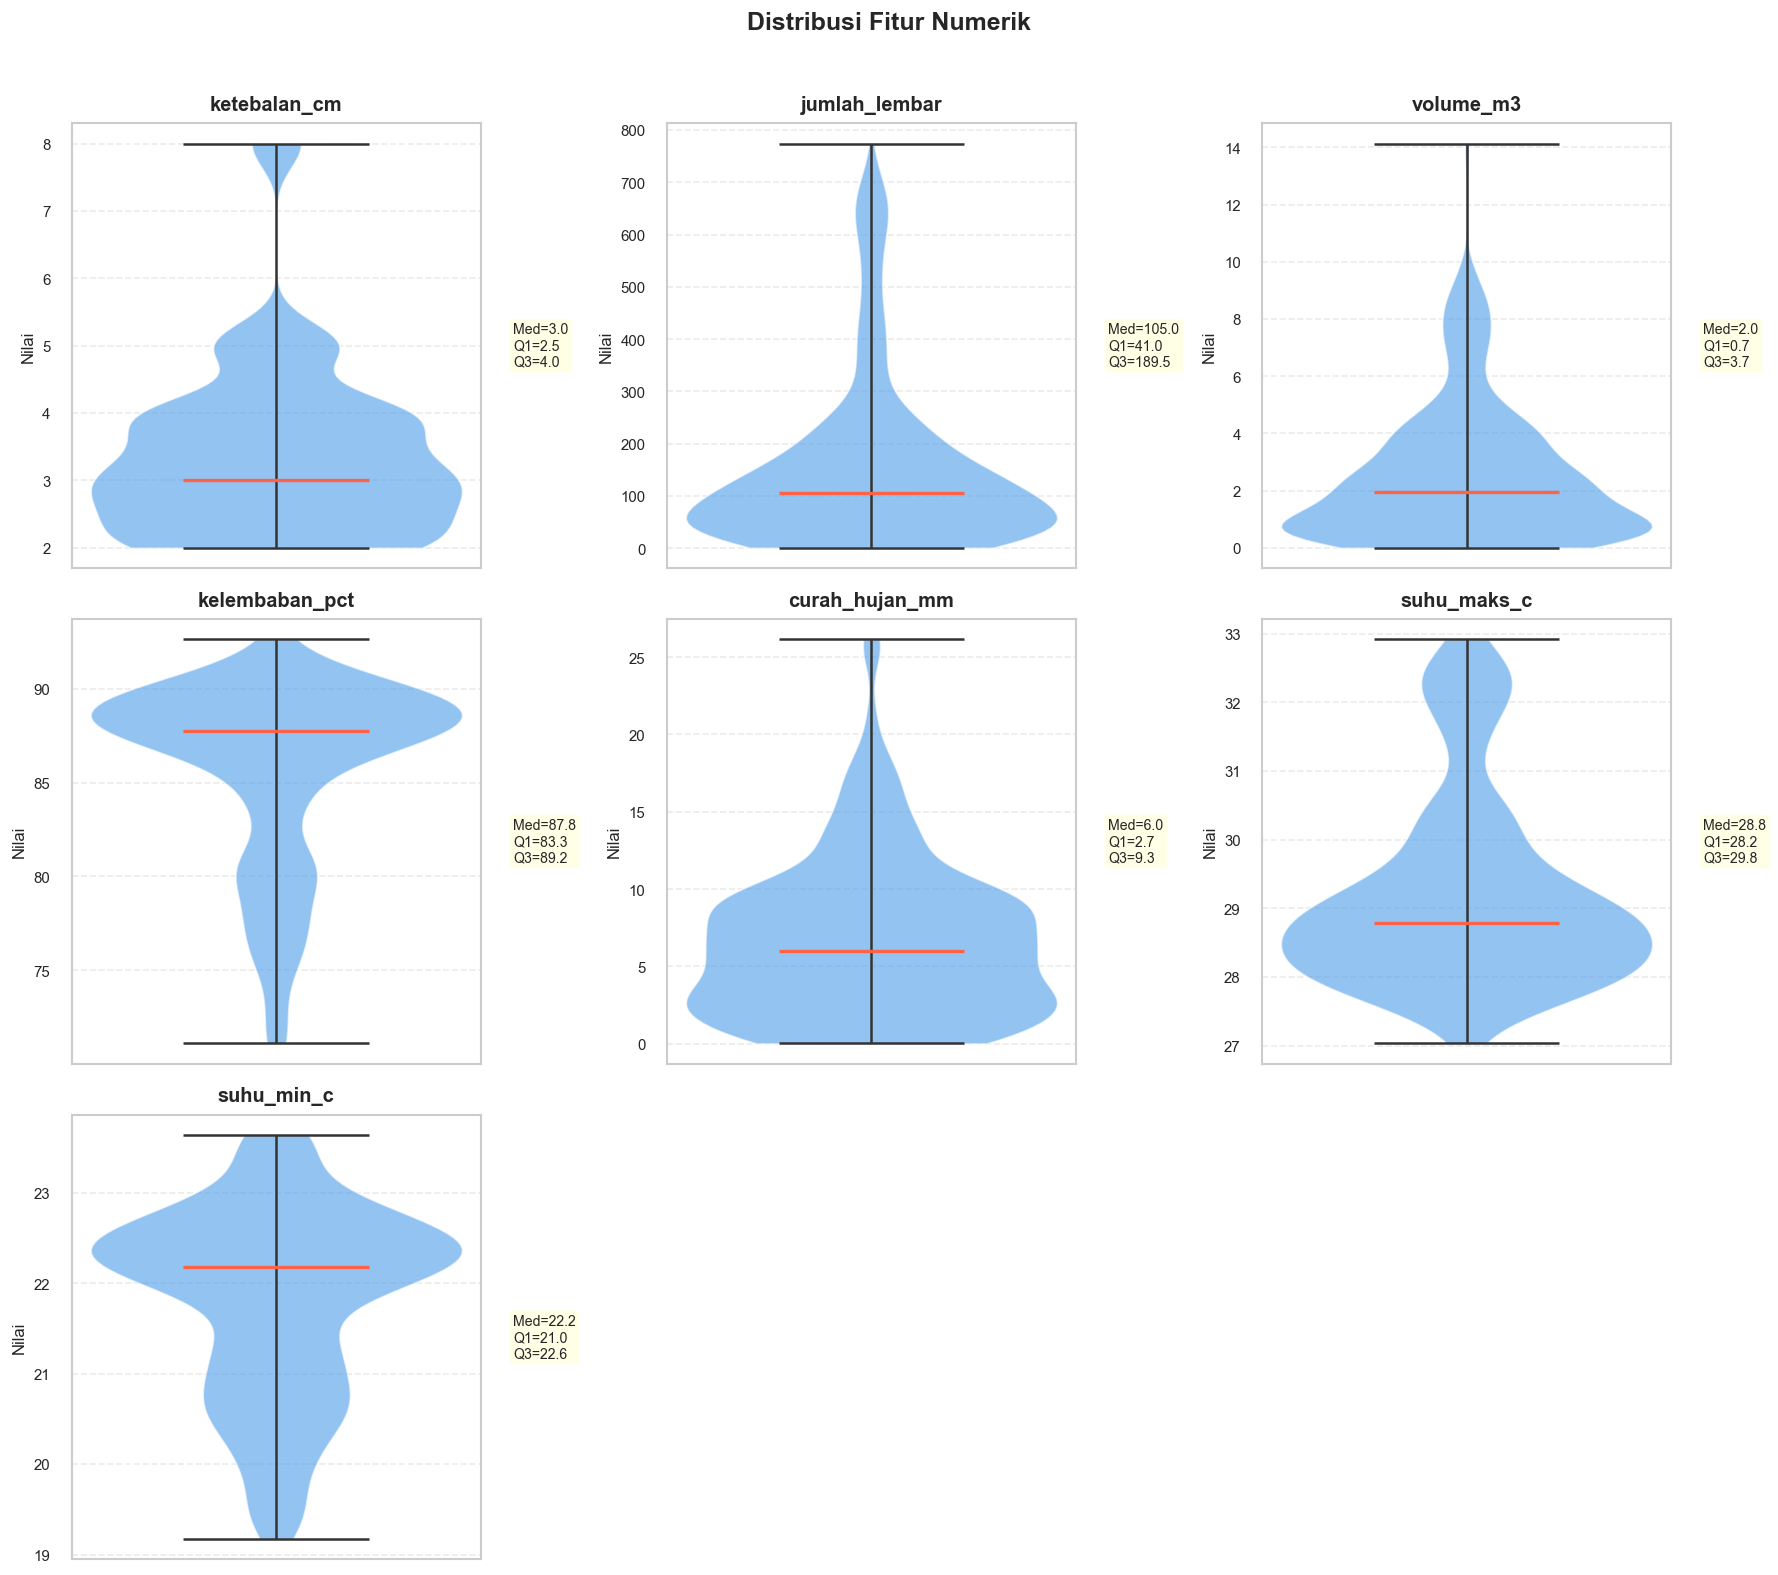

Tersimpan: gambar/fig_4_2_4_distribusi_numerik.png


In [52]:
# =============================================================================
# 4.2.4 — DISTRIBUSI FITUR NUMERIK (Violin) — layout grid 3-2-2
# =============================================================================
import os
import math
os.makedirs('gambar', exist_ok=True)

num_feats = ['ketebalan_cm', 'jumlah_lembar', 'volume_m3',
             'kelembaban_pct', 'curah_hujan_mm', 'suhu_maks_c', 'suhu_min_c']

NCOLS = 3
NROWS = math.ceil(len(num_feats) / NCOLS)   # = 3

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(15, 13))
fig.suptitle('Distribusi Fitur Numerik', fontsize=15, fontweight='bold', y=1.01)

axes_flat = axes.flatten()

for i, col in enumerate(num_feats):
    ax = axes_flat[i]
    data = df_raw[col].dropna()

    parts = ax.violinplot(data, vert=True, showmedians=True,
                          showextrema=True, widths=0.7)

    # Warna violin
    for pc in parts['bodies']:
        pc.set_facecolor('#4C9BE8')
        pc.set_alpha(0.6)
    parts['cmedians'].set_color('tomato')
    parts['cmedians'].set_linewidth(2)
    parts['cmaxes'].set_color('#333333')
    parts['cmins'].set_color('#333333')
    parts['cbars'].set_color('#333333')

    # Statistik ringkas di dalam plot
    q1, median, q3 = data.quantile([0.25, 0.5, 0.75])
    ax.set_title(col, fontsize=12, fontweight='bold', pad=8)
    ax.set_ylabel('Nilai', fontsize=10)
    ax.set_xticks([])
    ax.tick_params(axis='y', labelsize=9)

    # Anotasi ringkas
    ax.annotate(f'Med={median:.1f}\nQ1={q1:.1f}\nQ3={q3:.1f}',
                xy=(1.08, 0.5), xycoords='axes fraction',
                fontsize=8.5, va='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

    ax.grid(axis='y', linestyle='--', alpha=0.4)

# Sembunyikan subplot kosong (slot ke-8 dan ke-9)
for j in range(len(num_feats), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
fname = 'gambar/fig_4_2_4_distribusi_numerik.png'
fig.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'Tersimpan: {fname}')

### 4.2.5 Analisis Korelasi & Outlier

In [53]:
# =============================================================================
# 4.2.5 — HEATMAP KORELASI
# =============================================================================

num_for_corr = ['durasi_hari','ketebalan_cm','jumlah_lembar','volume_m3',
                'vol_total_m3','kelembaban_pct','curah_hujan_mm','suhu_maks_c','suhu_min_c']

corr_matrix = df_raw[num_for_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Heatmap Korelasi Antar Variabel Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig("gambar/fig_4_2_5_heatmap_korelasi.png", dpi=150, bbox_inches="tight")
plt.close()
plt.show()

print("Korelasi terhadap durasi_hari (diurutkan):")
print(corr_matrix['durasi_hari'].drop('durasi_hari').sort_values(ascending=False).round(3).to_string())


Korelasi terhadap durasi_hari (diurutkan):
curah_hujan_mm    0.391
kelembaban_pct    0.324
suhu_min_c        0.304
ketebalan_cm      0.124
volume_m3         0.018
jumlah_lembar    -0.011
vol_total_m3     -0.049
suhu_maks_c      -0.303


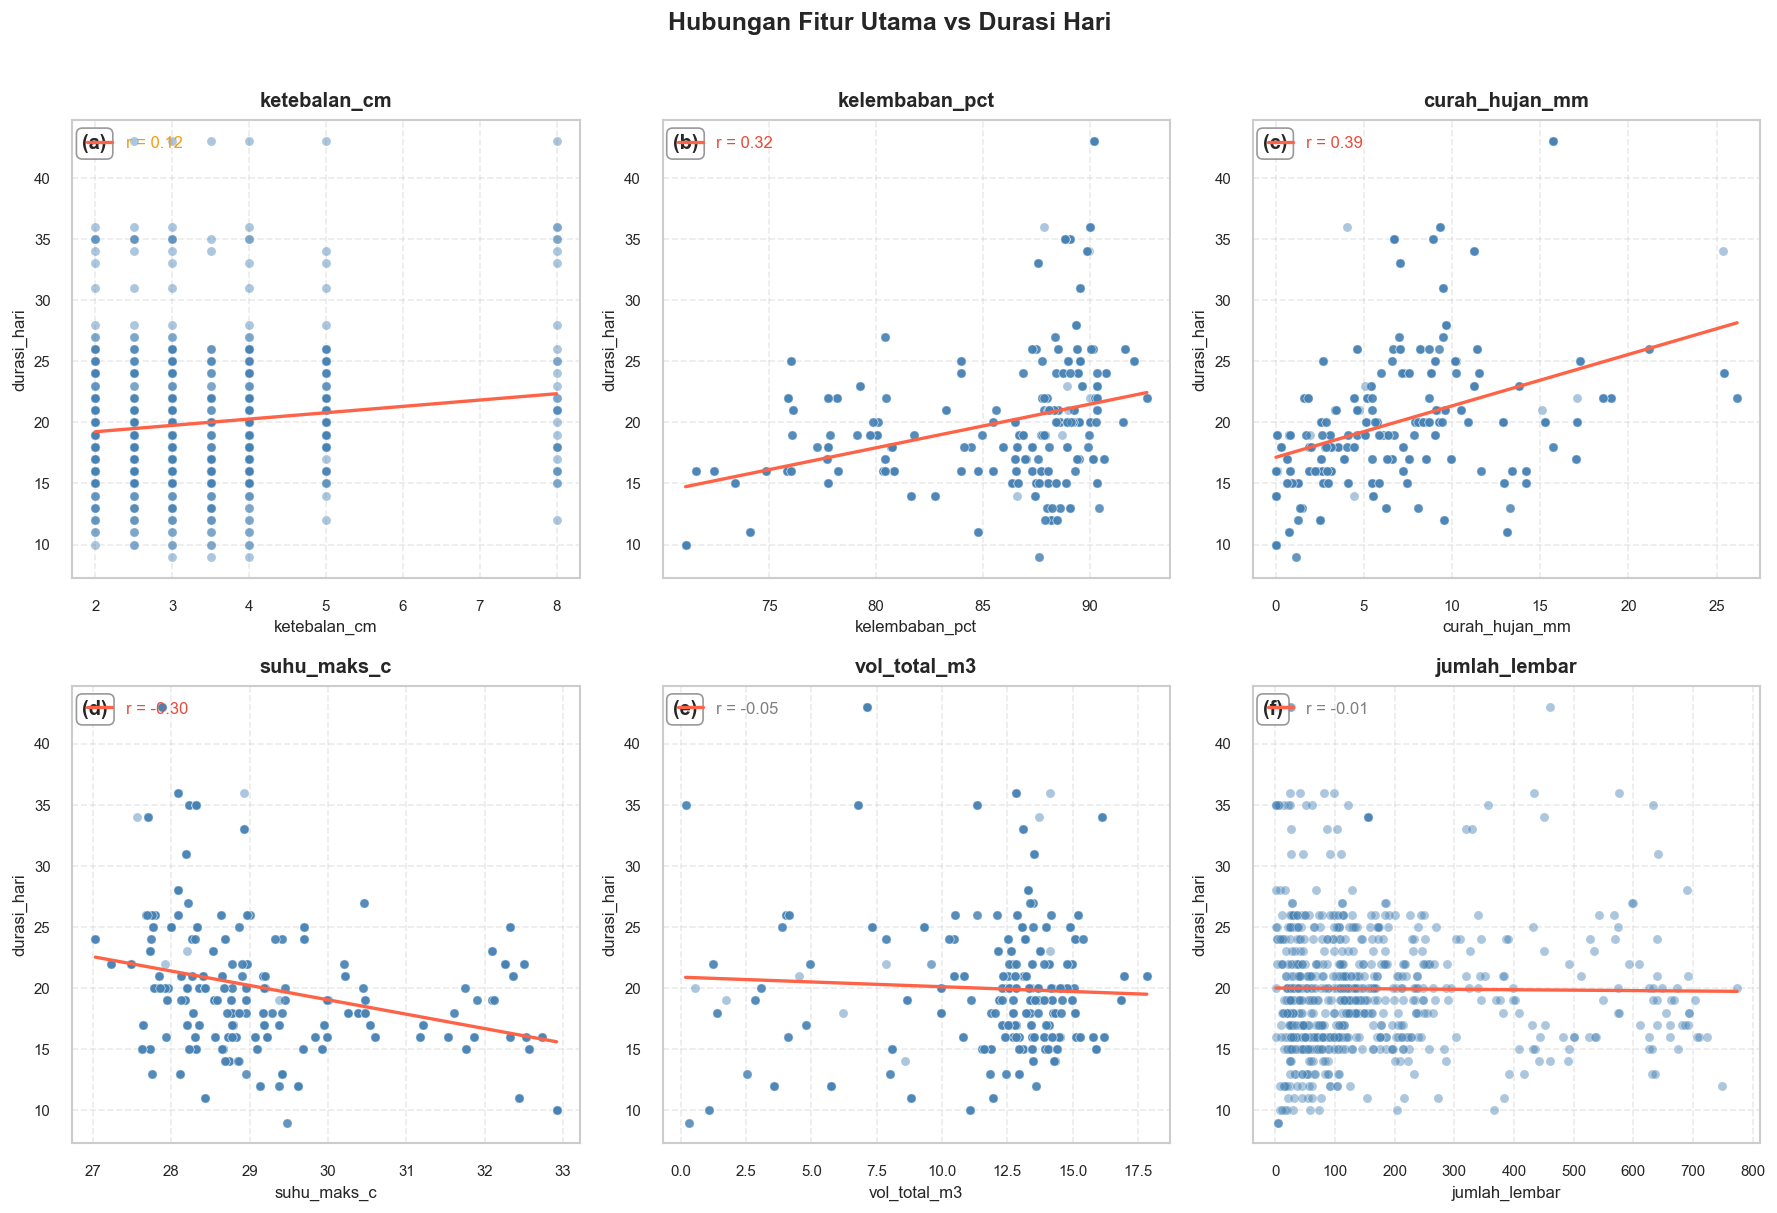

Tersimpan: gambar/fig_4_2_5_scatter_fitur.png


In [54]:
# =============================================================================
# 4.2.5 — SCATTER PLOT: FITUR UTAMA vs TARGET — 1 gambar grid 2x3
# =============================================================================

top_feats = ['ketebalan_cm', 'kelembaban_pct', 'curah_hujan_mm',
             'suhu_maks_c', 'vol_total_m3', 'jumlah_lembar']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Hubungan Fitur Utama vs Durasi Hari', fontsize=15, fontweight='bold', y=1.01)

axes_flat = axes.flatten()
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

for i, (feat, label) in enumerate(zip(top_feats, labels)):
    ax = axes_flat[i]

    x = df_raw[feat].dropna()
    y = df_raw.loc[x.index, 'durasi_hari']
    r = x.corr(y)

    # Scatter
    ax.scatter(x, y, alpha=0.45, s=30, color='steelblue', edgecolors='white', linewidths=0.3)

    # Garis regresi
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m * xline + b, color='tomato', linewidth=2,
            label=f'r = {r:.2f}')

    # Warna label korelasi berdasarkan kekuatan
    r_color = '#e74c3c' if abs(r) >= 0.3 else '#f39c12' if abs(r) >= 0.1 else 'gray'
    legend = ax.legend(fontsize=10, loc='upper left',
                       handlelength=1.5, framealpha=0.85)
    legend.get_texts()[0].set_color(r_color)

    # Label (a), (b), (c), ... di pojok kiri atas dalam kotak
    ax.text(0.02, 0.97, label, transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))

    ax.set_title(feat, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('durasi_hari', fontsize=10)
    ax.tick_params(labelsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
fname = 'gambar/fig_4_2_5_scatter_fitur.png'
fig.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'Tersimpan: {fname}')

In [55]:
# =============================================================================
# 4.2.5 — DETEKSI OUTLIER (IQR)
# =============================================================================

def outlier_iqr(series: pd.Series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((series < lower) | (series > upper)).sum()
    return pd.Series({'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'Lower': lower, 'Upper': upper, 'Outlier': n_out})

out_cols = ['durasi_hari','ketebalan_cm','kelembaban_pct','curah_hujan_mm','suhu_maks_c','suhu_min_c']
outlier_report = df_raw[out_cols].apply(outlier_iqr).T.round(2)
print("Laporan Outlier (Metode IQR):")
outlier_report


Laporan Outlier (Metode IQR):


,Q1,Q3,IQR,Lower,Upper,Outlier
durasi_hari,16.00,22.00,6.00,7.00,31.00,38.0
ketebalan_cm,2.50,4.00,1.50,0.25,6.25,32.0
kelembaban_pct,83.28,89.16,5.88,74.47,97.97,29.0
curah_hujan_mm,2.70,9.33,6.63,-7.24,19.27,14.0
suhu_maks_c,28.21,29.84,1.63,25.76,32.28,49.0
suhu_min_c,20.99,22.56,1.57,18.63,24.92,0.0


### 4.2.6 Analisis Temporal

In [56]:
# =============================================================================
# 4.2.6 — ANALISIS TEMPORAL: DURASI PER BULAN
# =============================================================================

df_raw['bulan'] = df_raw['tanggal_in'].dt.month
monthly = df_raw.groupby('bulan')['durasi_hari'].agg(['mean','std','count']).round(2)
monthly.columns = ['Rata-rata (hari)', 'Std Dev', 'Jumlah Batch']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Temporal Durasi Pengeringan', fontsize=14, fontweight='bold')

# Rata-rata durasi per bulan
bulan_label = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
bars = axes[0].bar(monthly.index, monthly['Rata-rata (hari)'], 
                   yerr=monthly['Std Dev'], capsize=4,
                   color=sns.color_palette('coolwarm', 12),
                   error_kw={'linewidth': 1.2, 'ecolor': 'gray'})
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(bulan_label, fontsize=9)
axes[0].set_title('Rata-rata Durasi per Bulan (± Std Dev)')
axes[0].set_ylabel('Durasi (hari)')

# Jumlah batch per bulan
axes[1].bar(monthly.index, monthly['Jumlah Batch'],
            color=sns.color_palette('muted', 12))
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(bulan_label, fontsize=9)
axes[1].set_title('Jumlah Batch per Bulan')
axes[1].set_ylabel('Jumlah Batch')

plt.tight_layout()
fig.savefig("gambar/fig_4_2_6_analisis_temporal.png", dpi=150, bbox_inches="tight")
plt.close()
plt.show()

print("Statistik durasi per bulan:")
print(monthly.to_string())


Statistik durasi per bulan:
       Rata-rata (hari)  Std Dev  Jumlah Batch
bulan                                         
1.0               17.73     3.13            11
2.0               21.14     5.93            29
3.0               17.20     2.92            25
4.0               21.71     8.57            24
5.0               16.47     5.09            19
6.0               21.41     4.42            27
7.0               20.78     3.98            18
8.0               18.50     4.26            20
9.0               19.42     3.65            24
10.0              21.72     4.82            25
11.0              19.62     4.58            32
12.0              22.41     8.74            29


---
## 4.3 Pengolahan Data

### 4.3.1 Preprocessing — Agregasi ke Level Batch


In [57]:
# =============================================================================
# 4.3.1 — AGREGASI: 755 baris per-ketebalan → 166 baris per-batch
# =============================================================================
# Alasan agregasi:
#   Data asli memiliki beberapa baris per batch (satu per ketebalan).
#   Agregasi memastikan 1 batch = 1 baris agar tidak terjadi pseudo-replication.

TEBAL_BINS = [2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 8.0]

def build_batch_aggregate(df: pd.DataFrame) -> pd.DataFrame:
    total_per_batch = df.groupby('batch_no')['jumlah_lembar'].sum()
    prop_dict = {}
    for t in TEBAL_BINS:
        grp = df[df['ketebalan_cm'] == t].groupby('batch_no')['jumlah_lembar'].sum()
        prop_dict[f'prop_{t}'] = grp / total_per_batch

    agg = df.groupby('batch_no').agg(
        jenis_kayu     = ('jenis_kayu',    'first'),
        asal_kayu      = ('asal_kayu',     'first'),
        no_kiln        = ('no_kiln',       'first'),
        durasi_hari    = ('durasi_hari',   'first'),
        vol_total_m3   = ('vol_total_m3',  'first'),
        total_lembar   = ('total_lembar',  'first'),
        kelembaban_pct = ('kelembaban_pct','first'),
        curah_hujan_mm = ('curah_hujan_mm','first'),
        suhu_maks_c    = ('suhu_maks_c',   'first'),
        suhu_min_c     = ('suhu_min_c',    'first'),
        ket_mean       = ('ketebalan_cm',  'mean'),
        ket_max        = ('ketebalan_cm',  'max'),
        ket_min        = ('ketebalan_cm',  'min'),
        ket_std        = ('ketebalan_cm',  'std'),
        n_ketebalan    = ('ketebalan_cm',  'nunique'),
        vol_m3_total   = ('volume_m3',     'sum'),
        lembar_total   = ('jumlah_lembar', 'sum'),
        bulan_in       = ('tanggal_in',    lambda x: x.dt.month.mode()[0] if x.notna().any() else 0),
    ).reset_index()

    for t in TEBAL_BINS:
        agg[f'prop_{t}'] = agg['batch_no'].map(prop_dict[f'prop_{t}']).fillna(0)

    agg['ket_std']        = agg['ket_std'].fillna(0)
    agg['jumlah_asal']    = agg['asal_kayu'].str.count(';') + 1
    agg['vol_per_lembar'] = agg['vol_m3_total'] / agg['lembar_total'].replace(0, 1)
    return agg

df_batch = build_batch_aggregate(df_raw)

print(f"Sebelum agregasi : {df_raw.shape[0]} baris × {df_raw.shape[1]} kolom")
print(f"Setelah agregasi : {df_batch.shape[0]} batch × {df_batch.shape[1]} kolom")
print(f"\nDistribusi jenis kayu:")
print(df_batch['jenis_kayu'].value_counts().to_string())
df_batch.head(3)


Sebelum agregasi : 755 baris × 18 kolom
Setelah agregasi : 166 batch × 28 kolom

Distribusi jenis kayu:
jenis_kayu
MAHONI    149
JATI       17


,batch_no,jenis_kayu,asal_kayu,no_kiln,durasi_hari,vol_total_m3,total_lembar,kelembaban_pct,curah_hujan_mm,suhu_maks_c,...,bulan_in,prop_2.0,prop_2.5,prop_3.0,prop_3.5,prop_4.0,prop_5.0,prop_8.0,jumlah_asal,vol_per_lembar
0,1,MAHONI,KLATEN,1,17,14.091,945,87.02,6.59,29.38,...,2,0.080423,0.720635,0.119577,0.049735,0.029630,0.0,0.0,1,0.014911
1,2,MAHONI,KLATEN,2,19,11.116,786,86.82,6.71,29.45,...,4,0.030534,0.699746,0.150127,0.000000,0.119593,0.0,0.0,1,0.014142
2,3,MAHONI,KLATEN,4,24,7.865,529,86.87,7.26,29.42,...,5,0.030246,0.650284,0.200378,0.000000,0.119093,0.0,0.0,1,0.014868


### 4.3.2 Feature Engineering

In [58]:
# =============================================================================
# 4.3.2 — FEATURE ENGINEERING
# =============================================================================

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    d['delta_suhu']     = d['suhu_maks_c'] - d['suhu_min_c']
    d['musim']          = d['bulan_in'].apply(lambda m: 1 if m in [11,12,1,2,3,4] else 0)
    d['lembab_x_tebal'] = d['kelembaban_pct'] * d['ket_max']
    d['hujan_x_lembab'] = d['curah_hujan_mm'] * d['kelembaban_pct']
    d['tebal_x_vol']    = d['ket_mean']        * d['vol_total_m3']
    d['prop_tipis']     = d['prop_2.0'] + d['prop_2.5']
    d['prop_tebal_ext'] = d['prop_5.0'] + d['prop_8.0']
    d['rasio_tebal']    = d['prop_tebal_ext'] / (d['prop_tipis'] + 1e-6)
    return d

df_batch = engineer_features(df_batch)

fitur_baru = ['delta_suhu','musim','lembab_x_tebal','hujan_x_lembab',
              'tebal_x_vol','prop_tipis','prop_tebal_ext','rasio_tebal']
print("Fitur baru setelah feature engineering:")
for f in fitur_baru:
    print(f"  • {f}")
print(f"\nTotal kolom: {df_batch.shape[1]}")


Fitur baru setelah feature engineering:
  • delta_suhu
  • musim
  • lembab_x_tebal
  • hujan_x_lembab
  • tebal_x_vol
  • prop_tipis
  • prop_tebal_ext
  • rasio_tebal

Total kolom: 36


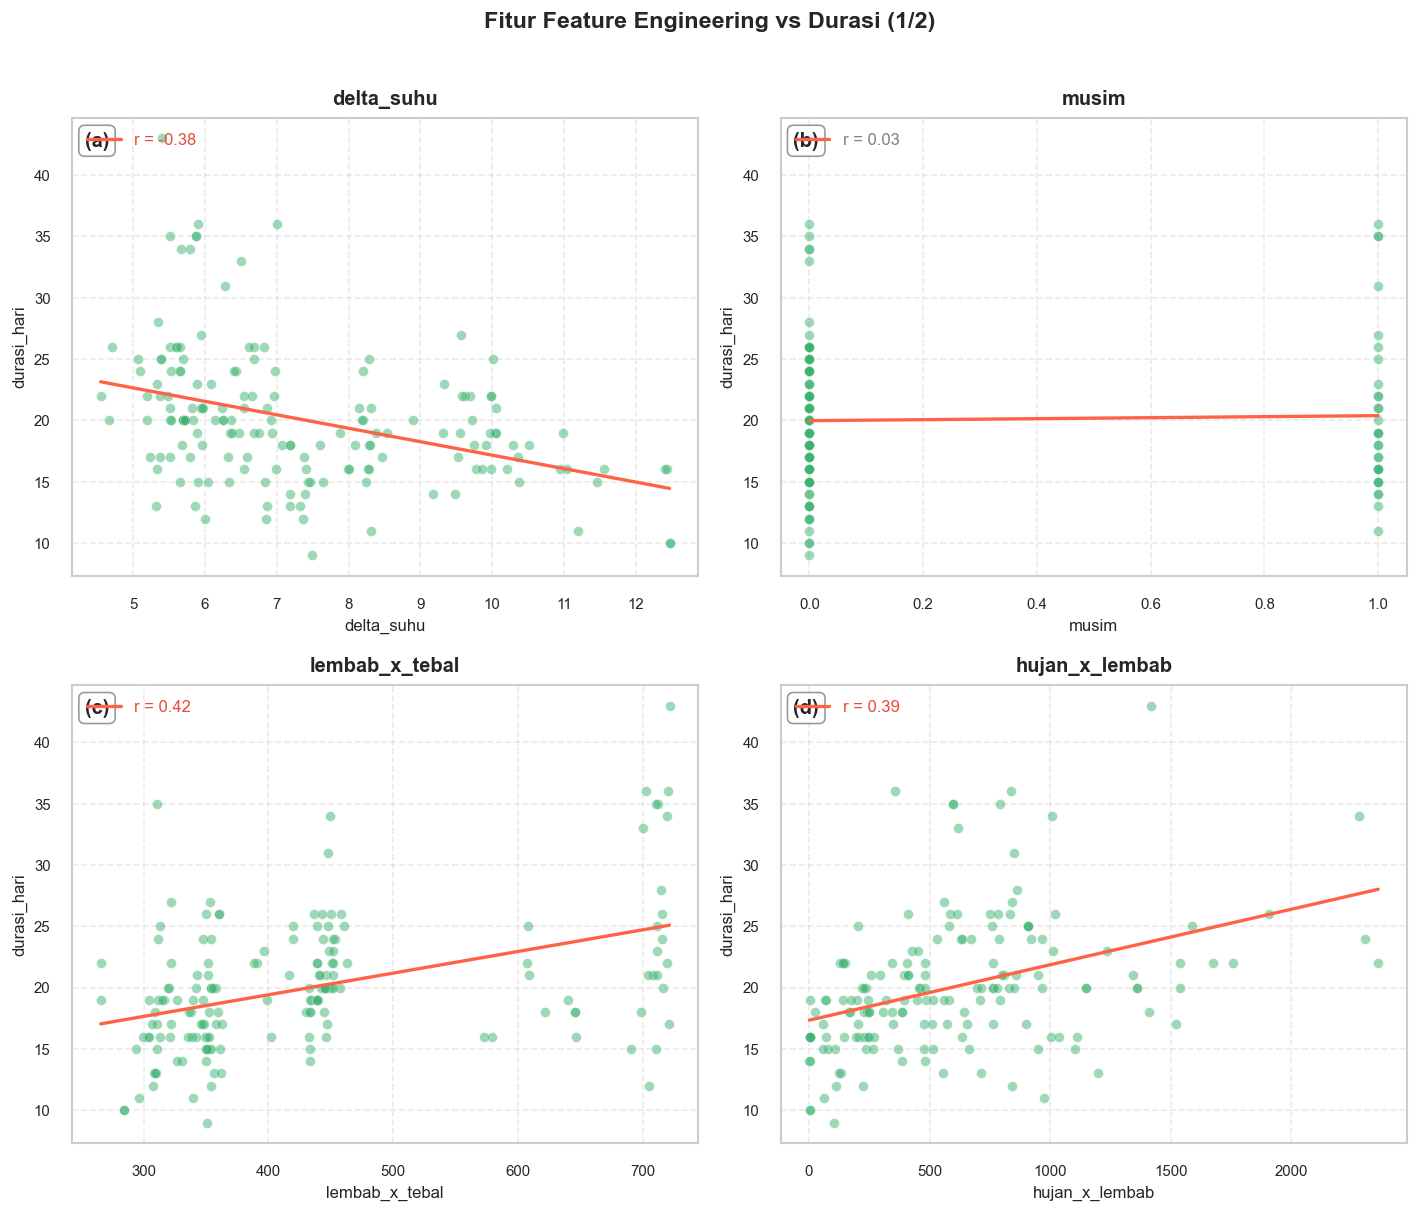

Tersimpan: gambar/fig_4_3_2_feature_eng_a.png


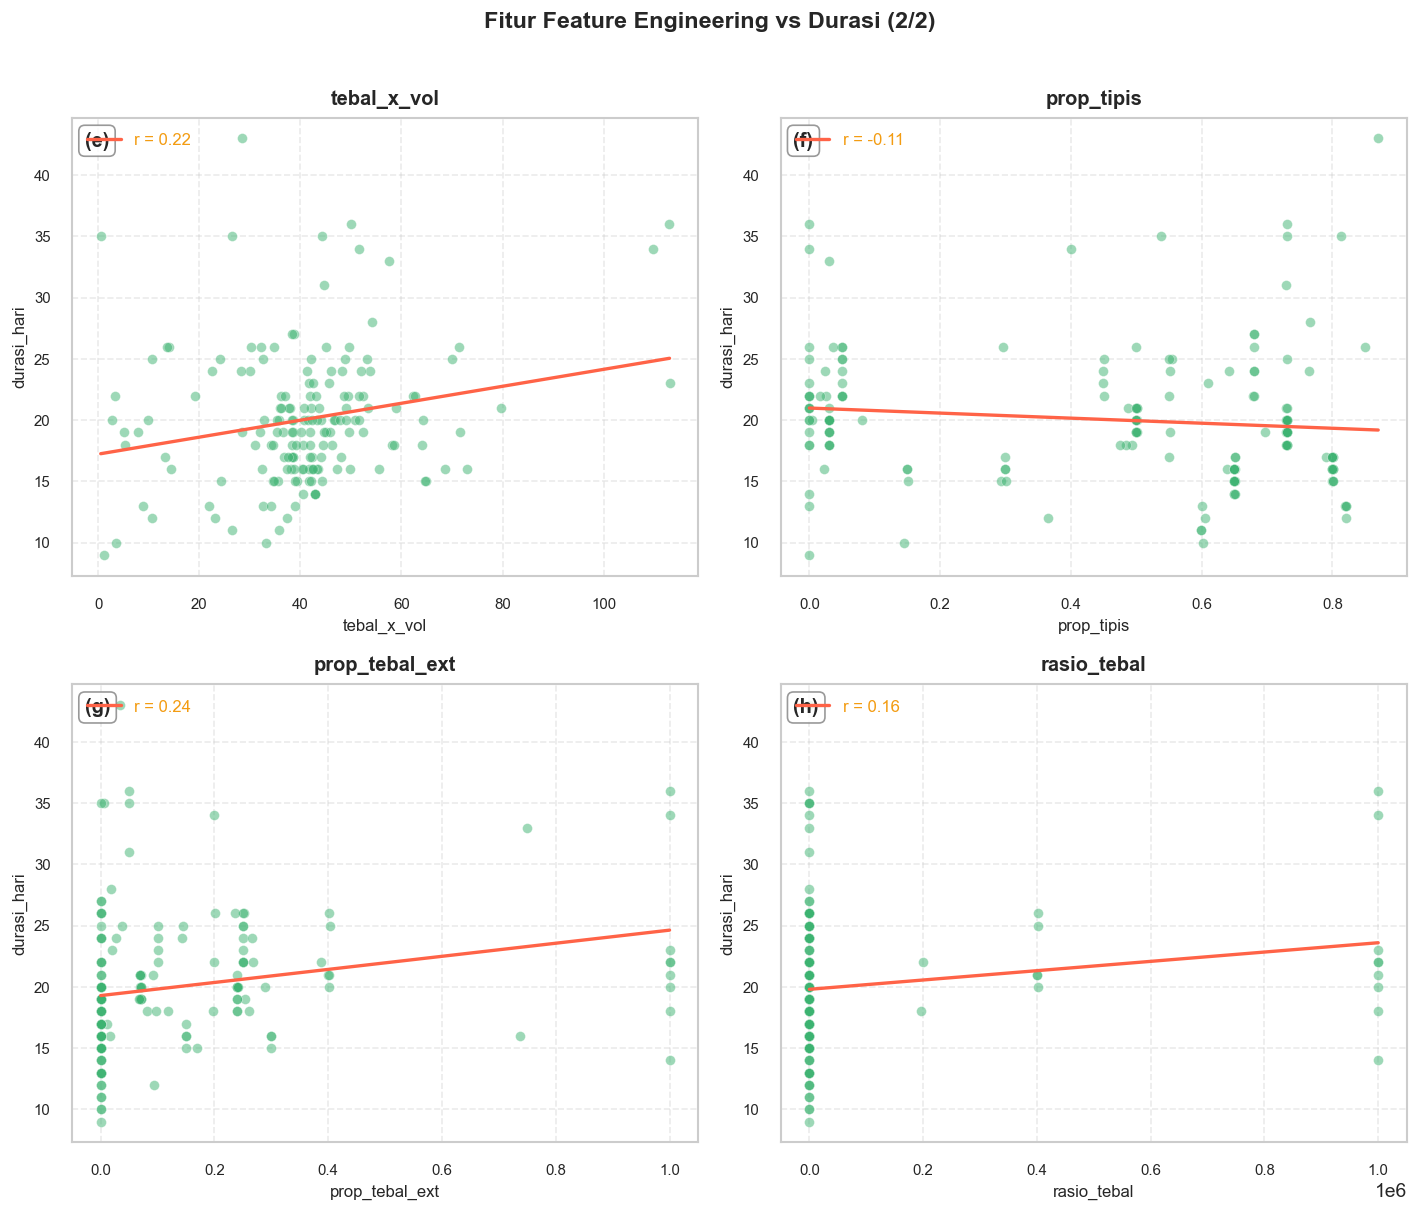

Tersimpan: gambar/fig_4_3_2_feature_eng_b.png


In [59]:
# =============================================================================
# 4.3.2 — VISUALISASI FITUR BARU vs TARGET — 2 gambar grid 2x2
# =============================================================================

splits25 = [fitur_baru[:4], fitur_baru[4:]]
fnames25 = ['fig_4_3_2_feature_eng_a.png', 'fig_4_3_2_feature_eng_b.png']
judul25  = ['Fitur Feature Engineering vs Durasi (1/2)',
             'Fitur Feature Engineering vs Durasi (2/2)']
labels25 = [['(a)', '(b)', '(c)', '(d)'],
             ['(e)', '(f)', '(g)', '(h)']]

for feats, fname, judul, labs in zip(splits25, fnames25, judul25, labels25):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(judul, fontsize=14, fontweight='bold', y=1.01)
    axes_flat = axes.flatten()

    for ax, feat, lab in zip(axes_flat, feats, labs):
        x = df_batch[feat]
        y = df_batch['durasi_hari']
        r = x.corr(y)

        ax.scatter(x, y, alpha=0.5, s=35, color='mediumseagreen',
                   edgecolors='white', linewidths=0.3)

        m, b = np.polyfit(x, y, 1)
        xline = np.linspace(x.min(), x.max(), 100)
        ax.plot(xline, m * xline + b, color='tomato', linewidth=2,
                label=f'r = {r:.2f}')

        # Warna label korelasi
        r_color = '#e74c3c' if abs(r) >= 0.3 else '#f39c12' if abs(r) >= 0.1 else 'gray'
        legend = ax.legend(fontsize=10, loc='upper left', framealpha=0.85)
        legend.get_texts()[0].set_color(r_color)

        # Label (a), (b), ...
        ax.text(0.02, 0.97, lab, transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))

        ax.set_title(feat, fontsize=12, fontweight='bold', pad=8)
        ax.set_xlabel(feat, fontsize=10)
        ax.set_ylabel('durasi_hari', fontsize=10)
        ax.tick_params(labelsize=9)
        ax.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    fig.savefig(f'gambar/{fname}', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Tersimpan: gambar/{fname}')

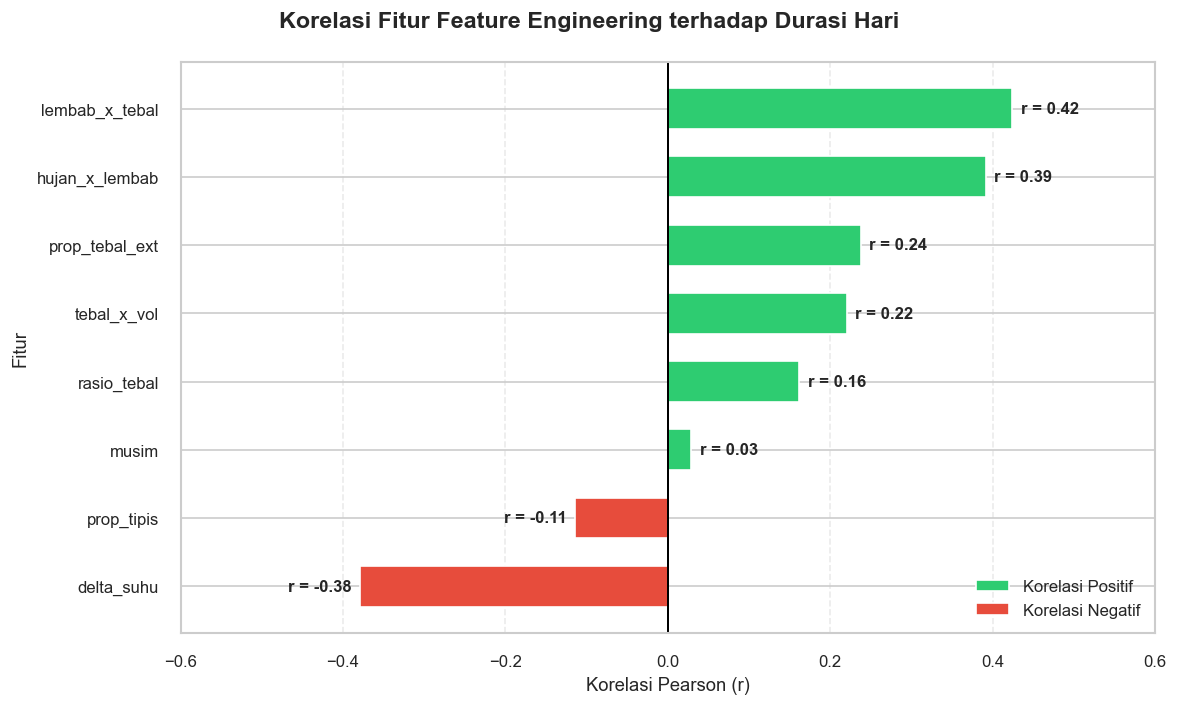

Tersimpan: gambar/fig_4_3_2_feature_eng_korelasi.png


In [60]:
# =============================================================================
# 4.3.2 — KORELASI FITUR REKAYASA vs TARGET — horizontal bar chart
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Korelasi Fitur Feature Engineering terhadap Durasi Hari',
             fontsize=14, fontweight='bold')

# Hitung korelasi semua fitur baru
corr_vals = {feat: df_batch[feat].corr(df_batch['durasi_hari']) for feat in fitur_baru}
corr_series = pd.Series(corr_vals).sort_values()

# Warna: merah jika negatif, hijau jika positif
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_series.values]

bars = ax.barh(corr_series.index, corr_series.values, color=colors,
               edgecolor='white', height=0.6)

# Anotasi nilai r di ujung setiap bar
for bar, val in zip(bars, corr_series.values):
    x_pos = val + 0.01 if val >= 0 else val - 0.01
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f'r = {val:.2f}', va='center', ha=ha,
            fontsize=10, fontweight='bold')

# Garis nol
ax.axvline(0, color='black', linewidth=1.2, linestyle='-')

# Grid dan label
ax.set_xlabel('Korelasi Pearson (r)', fontsize=11)
ax.set_ylabel('Fitur', fontsize=11)
ax.set_xlim(-0.6, 0.6)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.tick_params(labelsize=10)

# Legenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Korelasi Positif'),
                   Patch(facecolor='#e74c3c', label='Korelasi Negatif')]
ax.legend(handles=legend_elements, fontsize=10, loc='lower right')

plt.tight_layout()
fname = 'gambar/fig_4_3_2_feature_eng_korelasi.png'
fig.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'Tersimpan: {fname}')

### 4.3.3 Augmentasi Data

In [61]:
# =============================================================================
# STEP 4 — AUGMENTASI DATA
# Tiga teknik: (1) Gaussian Noise, (2) KNN Interpolation, (3) Targeted Oversampling
# Kolom '_is_synthetic' menandai data asli vs sintetis.
# =============================================================================

NUM_COLS = [
    'bulan_in','no_kiln','vol_total_m3','kelembaban_pct',
    'curah_hujan_mm','suhu_maks_c','suhu_min_c',
    'ket_mean','ket_std','ket_min','ket_max','n_ketebalan',
    'vol_m3_total','lembar_total','jumlah_asal',
    'vol_per_lembar','delta_suhu',
]
CAT_COLS = ['jenis_kayu','asal_kayu']

BOUNDS = {
    'kelembaban_pct' : (40.0, 100.0),
    'curah_hujan_mm' : (0.0,  None),
    'suhu_maks_c'    : (20.0, 40.0),
    'suhu_min_c'     : (15.0, 35.0),
    'ket_mean'       : (1.5,  10.0),
    'ket_std'        : (0.0,  5.0),
    'ket_min'        : (1.5,  10.0),
    'ket_max'        : (1.5,  10.0),
    'vol_total_m3'   : (0.1,  None),
    'vol_m3_total'   : (0.1,  None),
    'lembar_total'   : (1.0,  None),
    'n_ketebalan'    : (1.0,  7.0),
    'jumlah_asal'    : (1.0,  5.0),
    'bulan_in'       : (1.0,  12.0),
    'no_kiln'        : (1.0,  6.0),
    'durasi_hari'    : (5.0,  60.0),
}

def clip_row(row: pd.Series) -> pd.Series:
    """Terapkan batas fisik dan perbaiki inkonsistensi antar kolom."""
    for col, (lo, hi) in BOUNDS.items():
        if col in row.index:
            val = row[col]
            if lo is not None: val = max(val, lo)
            if hi is not None: val = min(val, hi)
            row[col] = val
    if row['suhu_maks_c'] <= row['suhu_min_c'] + 2:
        mid = (row['suhu_maks_c'] + row['suhu_min_c']) / 2
        row['suhu_maks_c'] = mid + 1
        row['suhu_min_c']  = mid - 1
    row['ket_min']        = min(row['ket_min'], row['ket_mean'])
    row['ket_max']        = max(row['ket_max'], row['ket_mean'])
    row['delta_suhu']     = row['suhu_maks_c'] - row['suhu_min_c']
    if row['lembar_total'] > 0:
        row['vol_per_lembar'] = row['vol_m3_total'] / row['lembar_total']
    row['durasi_hari'] = int(round(row['durasi_hari']))
    row['bulan_in']    = int(round(row['bulan_in']))
    row['no_kiln']     = int(round(row['no_kiln']))
    return row


def gaussian_noise_augment(df, n_samples=200, noise_pct=0.04, seed=SEED):
    rng  = np.random.default_rng(seed)
    base = df.sample(n=n_samples, replace=True, random_state=seed).reset_index(drop=True)
    synth = base.copy()
    for col in NUM_COLS + ['durasi_hari']:
        if col not in df.columns: continue
        sigma       = df[col].std(ddof=1) * noise_pct
        synth[col] += rng.normal(0, sigma, size=n_samples)
    synth = synth.apply(clip_row, axis=1)
    return synth


def knn_interpolation_augment(df, n_samples=150, k=5, seed=SEED):
    rng      = np.random.default_rng(seed)
    num_data = df[NUM_COLS].fillna(0)
    col_std  = num_data.std().replace(0, 1)
    num_norm = (num_data - num_data.mean()) / col_std
    nbrs     = NearestNeighbors(n_neighbors=k+1, algorithm='ball_tree').fit(num_norm)
    _, indices = nbrs.kneighbors(num_norm)
    synth_rows  = []
    idx_choices = rng.integers(0, len(df), size=n_samples)
    for idx in idx_choices:
        nbr_rank = rng.integers(1, k+1)
        nbr_idx  = indices[idx][nbr_rank]
        row_a    = df.iloc[idx].copy()
        row_b    = df.iloc[nbr_idx].copy()
        alpha    = rng.uniform(0.1, 0.9)
        new_row  = row_a.copy()
        for col in NUM_COLS + ['durasi_hari']:
            if col in df.columns:
                new_row[col] = alpha * row_a[col] + (1 - alpha) * row_b[col]
        for col in CAT_COLS:
            new_row[col] = row_a[col]
        new_row = clip_row(new_row)
        synth_rows.append(new_row)
    return pd.DataFrame(synth_rows).reset_index(drop=True)


def targeted_oversampling(df, seed=SEED):
    groups  = {
        'durasi_pendek' : df[df['durasi_hari'] < 13],
        'durasi_panjang': df[df['durasi_hari'] > 30],
        'jati'          : df[df['jenis_kayu'] == 'JATI'],
    }
    targets = {'durasi_pendek': 40, 'durasi_panjang': 40, 'jati': 50}
    frames  = []
    for name, subset in groups.items():
        if len(subset) == 0: continue
        synth = gaussian_noise_augment(subset, n_samples=targets[name],
                                       noise_pct=0.05, seed=seed)
        synth['_aug_source'] = name
        frames.append(synth)
        print(f"  [Targeted] {name:16s}: {len(subset):3d} asli → +{targets[name]} sintetis")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def augment_pipeline(df_batch, n_gaussian=200, n_knn=150, knn_k=5):
    print("=" * 60)
    print("  PIPELINE AUGMENTASI DATA BATCH AGREGAT")
    print("=" * 60)
    print(f"\n  Data asli  : {len(df_batch):4d} batch")

    df_real = df_batch.copy()
    df_real['_is_synthetic'] = False
    df_real['_aug_source']   = 'real'

    print(f"\n[1] Gaussian Noise Augmentation (n={n_gaussian})")
    df_gauss = gaussian_noise_augment(df_batch, n_samples=n_gaussian)
    df_gauss['_is_synthetic'] = True
    df_gauss['_aug_source']   = 'gaussian'

    print(f"[2] KNN Interpolation (n={n_knn}, k={knn_k})")
    df_knn = knn_interpolation_augment(df_batch, n_samples=n_knn, k=knn_k)
    df_knn['_is_synthetic'] = True
    df_knn['_aug_source']   = 'knn_interp'

    print(f"[3] Targeted Oversampling")
    df_tgt = targeted_oversampling(df_batch)
    df_tgt['_is_synthetic'] = True

    df_aug = pd.concat([df_real, df_gauss, df_knn, df_tgt], ignore_index=True)
    df_aug = engineer_features(df_aug)   # recalculate fitur turunan agar konsisten

    print(f"\n{'─'*60}")
    print(f"  Total setelah augmentasi : {len(df_aug):4d} sampel")
    print(f"  Data asli                : {df_aug['_is_synthetic'].eq(False).sum():4d}")
    print(f"  Data sintetis            : {df_aug['_is_synthetic'].eq(True).sum():4d}")
    print(f"{'─'*60}")
    return df_aug


df_aug = augment_pipeline(df_batch, n_gaussian=200, n_knn=150, knn_k=5)
print(f"\nDistribusi durasi setelah augmentasi:")
print(df_aug['durasi_hari'].describe().round(2))

  PIPELINE AUGMENTASI DATA BATCH AGREGAT

  Data asli  :  166 batch

[1] Gaussian Noise Augmentation (n=200)
[2] KNN Interpolation (n=150, k=5)
[3] Targeted Oversampling
  [Targeted] durasi_pendek   :   8 asli → +40 sintetis
  [Targeted] durasi_panjang  :  10 asli → +40 sintetis
  [Targeted] jati            :  17 asli → +50 sintetis

────────────────────────────────────────────────────────────
  Total setelah augmentasi :  646 sampel
  Data asli                :  166
  Data sintetis            :  480
────────────────────────────────────────────────────────────

Distribusi durasi setelah augmentasi:
count    646.00
mean      20.22
std        6.68
min        9.00
25%       16.00
50%       19.00
75%       22.00
max       43.00
Name: durasi_hari, dtype: float64


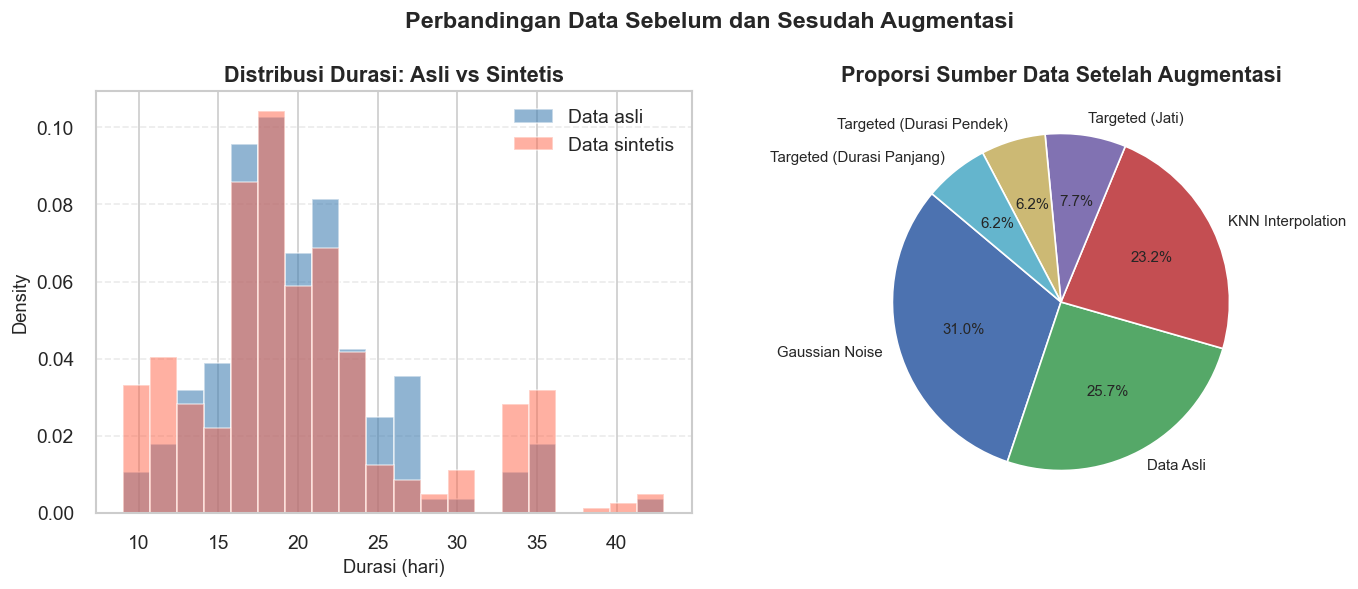

In [62]:
# =============================================================================
# 4.3.3 — VISUALISASI AUGMENTASI — 2 panel
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Perbandingan Data Sebelum dan Sesudah Augmentasi',
             fontsize=14, fontweight='bold')

# Panel 1 — Histogram distribusi durasi
ax = axes[0]
ax.hist(df_aug[df_aug['_aug_source']=='real']['durasi_hari'],
        bins=20, alpha=0.6, color='steelblue', label='Data asli', density=True)
ax.hist(df_aug[df_aug['_is_synthetic']==True]['durasi_hari'],
        bins=20, alpha=0.5, color='tomato',    label='Data sintetis', density=True)
ax.set_title('Distribusi Durasi: Asli vs Sintetis', fontweight='bold')
ax.set_xlabel('Durasi (hari)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Panel 2 — Pie chart proporsi sumber
ax = axes[1]
source_counts = df_aug['_aug_source'].value_counts()
label_map = {'real':'Data Asli', 'gaussian':'Gaussian Noise',
             'knn_interp':'KNN Interpolation',
             'durasi_pendek':'Targeted (Durasi Pendek)',
             'durasi_panjang':'Targeted (Durasi Panjang)',
             'jati':'Targeted (Jati)'}
labels = [label_map.get(k, k) for k in source_counts.index]
colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974','#64B5CD']
ax.pie(source_counts.values, labels=labels, autopct='%1.1f%%',
       colors=colors[:len(source_counts)], startangle=140,
       textprops={'fontsize': 9})
ax.set_title('Proporsi Sumber Data Setelah Augmentasi', fontweight='bold')

plt.tight_layout()
fname = 'gambar/fig_4_3_3_augmentasi.png'
fig.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [63]:
from pycaret.regression import (
    setup, compare_models, tune_model, blend_models,
    finalize_model, predict_model, plot_model,
    pull, save_model, load_model
)

COLS_DROP    = ['batch_no', 'asal_kayu', '_is_synthetic', '_aug_source']
CAT_FEATURES = ['jenis_kayu', 'no_kiln', 'bulan_in', 'musim']

df_asli  = df_aug[~df_aug['_is_synthetic']].copy()
df_synth = df_aug[ df_aug['_is_synthetic']].copy()

df_orig_train, df_orig_test = train_test_split(df_asli, test_size=0.2, random_state=SEED)
df_train = pd.concat([df_orig_train, df_synth], ignore_index=True)

for df in [df_train, df_orig_test]:
    for col in COLS_DROP:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)
    for col in CAT_FEATURES:
        df[col] = df[col].astype(str)

s = setup(
    data                     = df_train,
    target                   = 'durasi_hari',
    categorical_features     = CAT_FEATURES,
    max_encoding_ohe         = 15,
    normalize                = True,
    normalize_method         = 'zscore',
    remove_outliers          = False,
    feature_selection        = True,
    feature_selection_method = 'classic',
    fold_strategy            = 'kfold',
    fold                     = 10,
    session_id               = SEED,
    verbose                  = False
)

### 4.4.2 Perbandingan Model

In [64]:
# =============================================================================
# 4.4.2 — COMPARE MODELS
# =============================================================================

best_models = compare_models(
    include          = ['lr', 'rf', 'gbr', 'xgboost', 'et'],
    sort             = 'rmse',
    n_select         = 3,
    cross_validation = True,
)

compare_result = pull()
print(compare_result.head(3)[['MAE','RMSE','MAPE','R2']].round(4).to_string())


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,1.1005,3.1963,1.7555,0.9225,0.0792,0.0552,0.5640
rf,Random Forest Regressor,1.6489,6.6704,2.5651,0.8402,0.1092,0.0800,0.3560
xgboost,Extreme Gradient Boosting,1.6268,7.0769,2.6183,0.8333,0.1135,0.0787,0.3230
gbr,Gradient Boosting Regressor,1.8332,7.1533,2.6260,0.8124,0.1158,0.0915,0.3770
lr,Linear Regression,3.9631,27.0375,5.1475,0.3792,0.2394,0.2077,1.4840


            MAE    RMSE    MAPE      R2
et       1.1005  1.7555  0.0552  0.9225
rf       1.6489  2.5651  0.0800  0.8402
xgboost  1.6268  2.6183  0.0787  0.8333


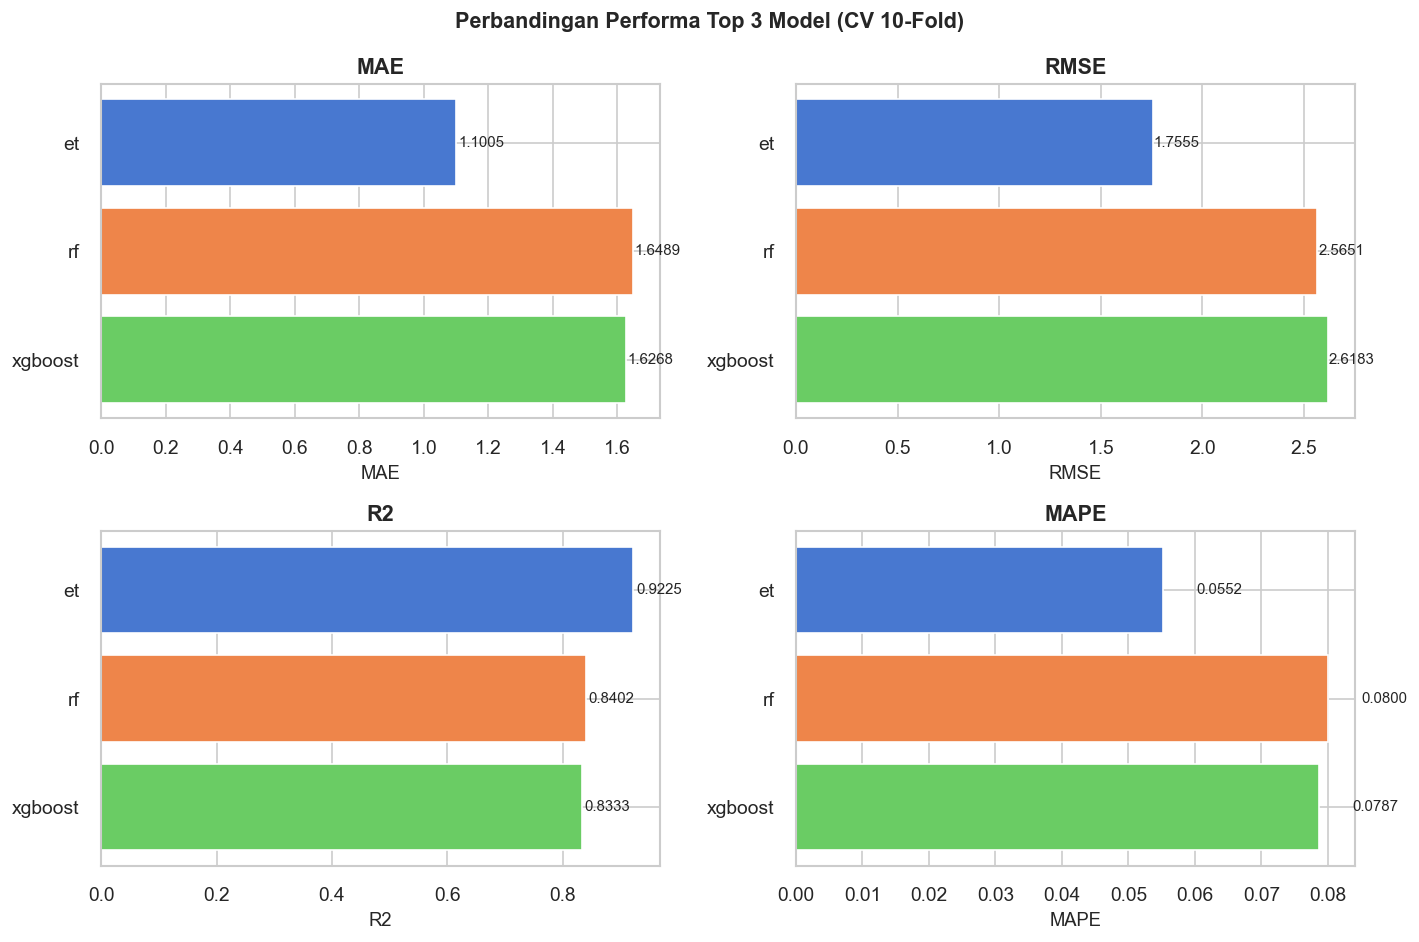

In [65]:
top3 = compare_result.head(3).copy()

# Kolom PyCaret v3 lowercase: mae, rmse, r2, mape
metrics_col   = ['MAE', 'RMSE', 'R2', 'MAPE']
metrics_label = ['MAE', 'RMSE', 'R2', 'MAPE']
n = len(top3)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Perbandingan Performa Top 3 Model (CV 10-Fold)', fontsize=13, fontweight='bold')
colors = sns.color_palette('muted', n)
axes = axes.flatten()

for i, (col, label) in enumerate(zip(metrics_col, metrics_label)):
    bars = axes[i].barh(top3.index, top3[col], color=colors)
    axes[i].set_title(label)
    axes[i].set_xlabel(label)
    for bar, val in zip(bars, top3[col]):
        axes[i].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                     f'{val:.4f}', va='center', fontsize=9)
    axes[i].invert_yaxis()

plt.tight_layout()
fig.savefig("gambar/fig_4_4_2_compare_models.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.4.3 Tuning & Blending

In [66]:
before_tuning = {
    'MAE' : compare_result.iloc[0]['MAE'],
    'RMSE': compare_result.iloc[0]['RMSE'],
    'R2'  : compare_result.iloc[0]['R2'],
    'MAPE': compare_result.iloc[0]['MAPE'],
}

tuned_model = tune_model(
    best_models[0],
    optimize                 = 'rmse',
    n_iter                   = 50,
    search_library           = 'optuna',
    search_algorithm         = 'tpe',
    early_stopping           = True,
    early_stopping_max_iters = 15,
)

tuning_df = pull()
mean_row  = tuning_df[tuning_df.index == 'Mean']

after_tuning = {
    'MAE' : float(mean_row['MAE'].values[0]),
    'RMSE': float(mean_row['RMSE'].values[0]),
    'R2'  : float(mean_row['R2'].values[0]),
    'MAPE': float(mean_row['MAPE'].values[0]),
}


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.4779,4.9089,2.2156,0.9132,0.0985,0.0744
1,0.9532,2.8432,1.6862,0.8857,0.0710,0.0484
2,1.0180,2.0236,1.4225,0.9421,0.0724,0.0586
3,1.3046,4.7489,2.1792,0.9176,0.1039,0.0675
4,1.4776,4.8124,2.1937,0.9232,0.0827,0.0641
5,1.2014,2.7129,1.6471,0.9594,0.0699,0.0537
6,1.0100,2.3456,1.5315,0.9530,0.0738,0.0517
7,1.5190,4.8445,2.2010,0.8656,0.0925,0.0757
8,1.3856,3.8849,1.9710,0.8381,0.0948,0.0741


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [67]:
# =============================================================================
# 4.4.3 — BLENDING (Ensemble Top 3)
# =============================================================================

blended_model = blend_models(
    estimator_list = best_models,
    optimize       = 'rmse'
)

blend_result = pull()
blend_mean   = blend_result[blend_result.index == 'Mean']
blend_metrics = {
    'MAE' : float(blend_mean['MAE'].values[0]),
    'RMSE': float(blend_mean['RMSE'].values[0]),
    'R2'  : float(blend_mean['R2'].values[0]),
    'MAPE': float(blend_mean['MAPE'].values[0]),
}


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.5879,6.1873,2.4874,0.8906,0.1025,0.0764
1,1.1326,4.9483,2.2245,0.8011,0.0982,0.0588
2,1.1533,2.7197,1.6491,0.9222,0.0860,0.0670
3,1.3903,5.7598,2.4000,0.9001,0.1078,0.0663
4,1.4488,4.8204,2.1955,0.9231,0.0825,0.0620
5,1.5893,5.4864,2.3423,0.9179,0.0917,0.0685
6,1.0259,2.3280,1.5258,0.9533,0.0744,0.0518
7,1.5975,5.4088,2.3257,0.8499,0.0916,0.0742
8,1.4617,4.4805,2.1167,0.8132,0.1027,0.0784


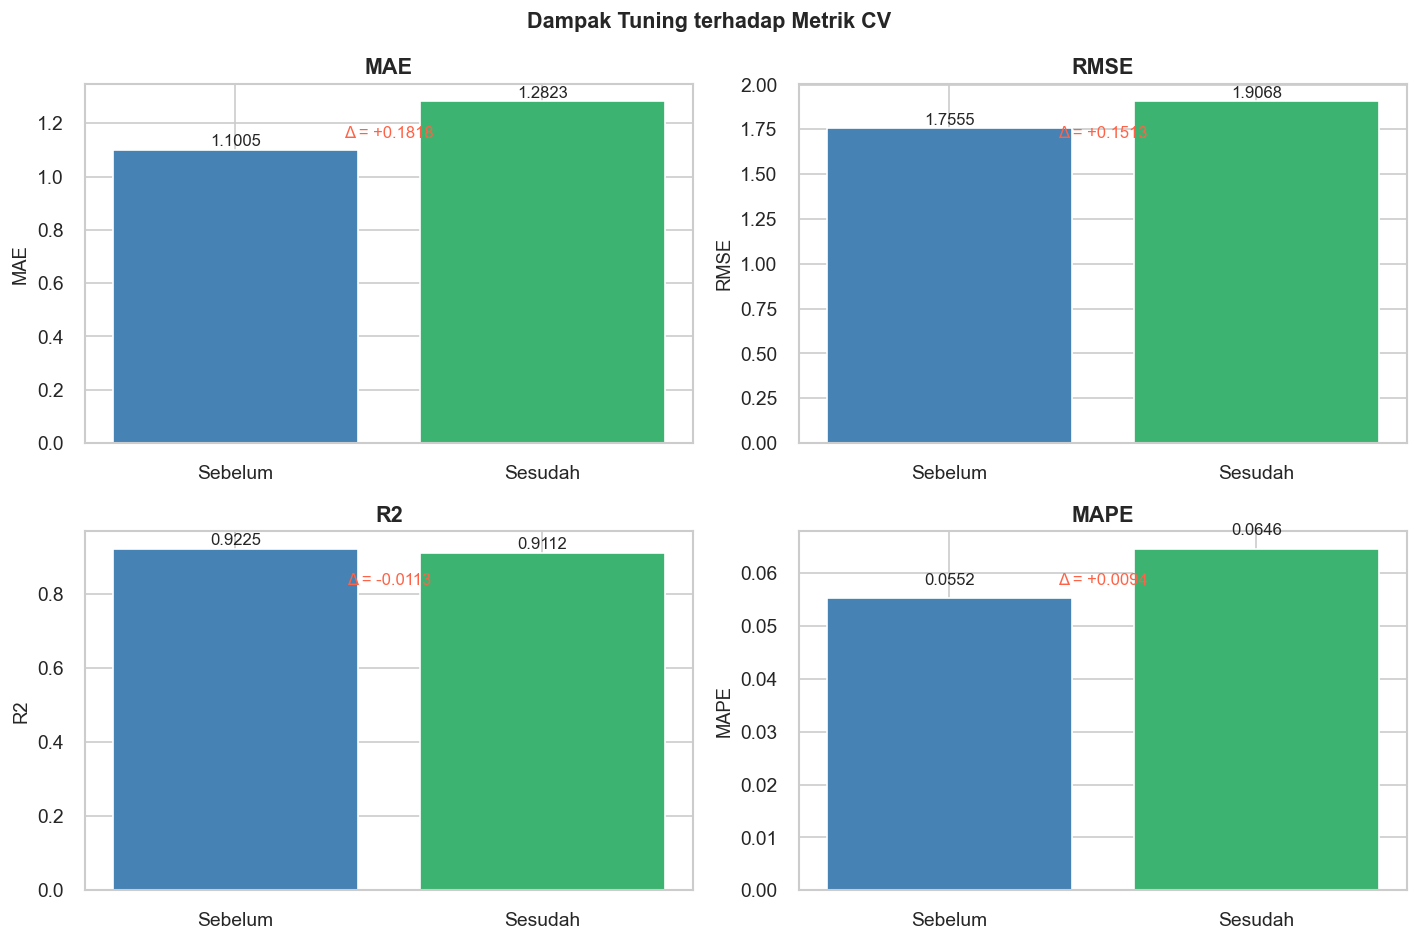

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Dampak Tuning terhadap Metrik CV', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, m in enumerate(['MAE', 'RMSE', 'R2', 'MAPE']):
    vals = [before_tuning[m], after_tuning[m]]
    bars = axes[i].bar(['Sebelum', 'Sesudah'], vals, color=['steelblue', 'mediumseagreen'])
    axes[i].set_title(m)
    axes[i].set_ylabel(m)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    delta     = after_tuning[m] - before_tuning[m]
    arrow_col = 'green' if (m == 'R2' and delta > 0) or (m != 'R2' and delta < 0) else 'tomato'
    axes[i].annotate(f'Δ = {delta:+.4f}', xy=(0.5, 0.85), xycoords='axes fraction',
                     ha='center', color=arrow_col, fontsize=10)

plt.tight_layout()
fig.savefig("gambar/fig_4_4_3_dampak_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

In [69]:
candidates = {
    'Baseline' : best_models[0],
    'Tuned'    : tuned_model,
    'Blended'  : blended_model,
}

scores = {
    'Baseline' : compare_result.iloc[0]['R2'],
    'Tuned'    : after_tuning['R2'],
    'Blended'  : blend_metrics['R2'],
}

chosen_name    = max(scores, key=scores.get)
final_cv_model = candidates[chosen_name]

print(f"R² Baseline : {scores['Baseline']:.4f}")
print(f"R² Tuned    : {scores['Tuned']:.4f}")
print(f"R² Blended  : {scores['Blended']:.4f}")
print(f"\n→ Model terpilih: {chosen_name} (R² = {scores[chosen_name]:.4f})")


R² Baseline : 0.9225
R² Tuned    : 0.9112
R² Blended  : 0.8854

→ Model terpilih: Baseline (R² = 0.9225)


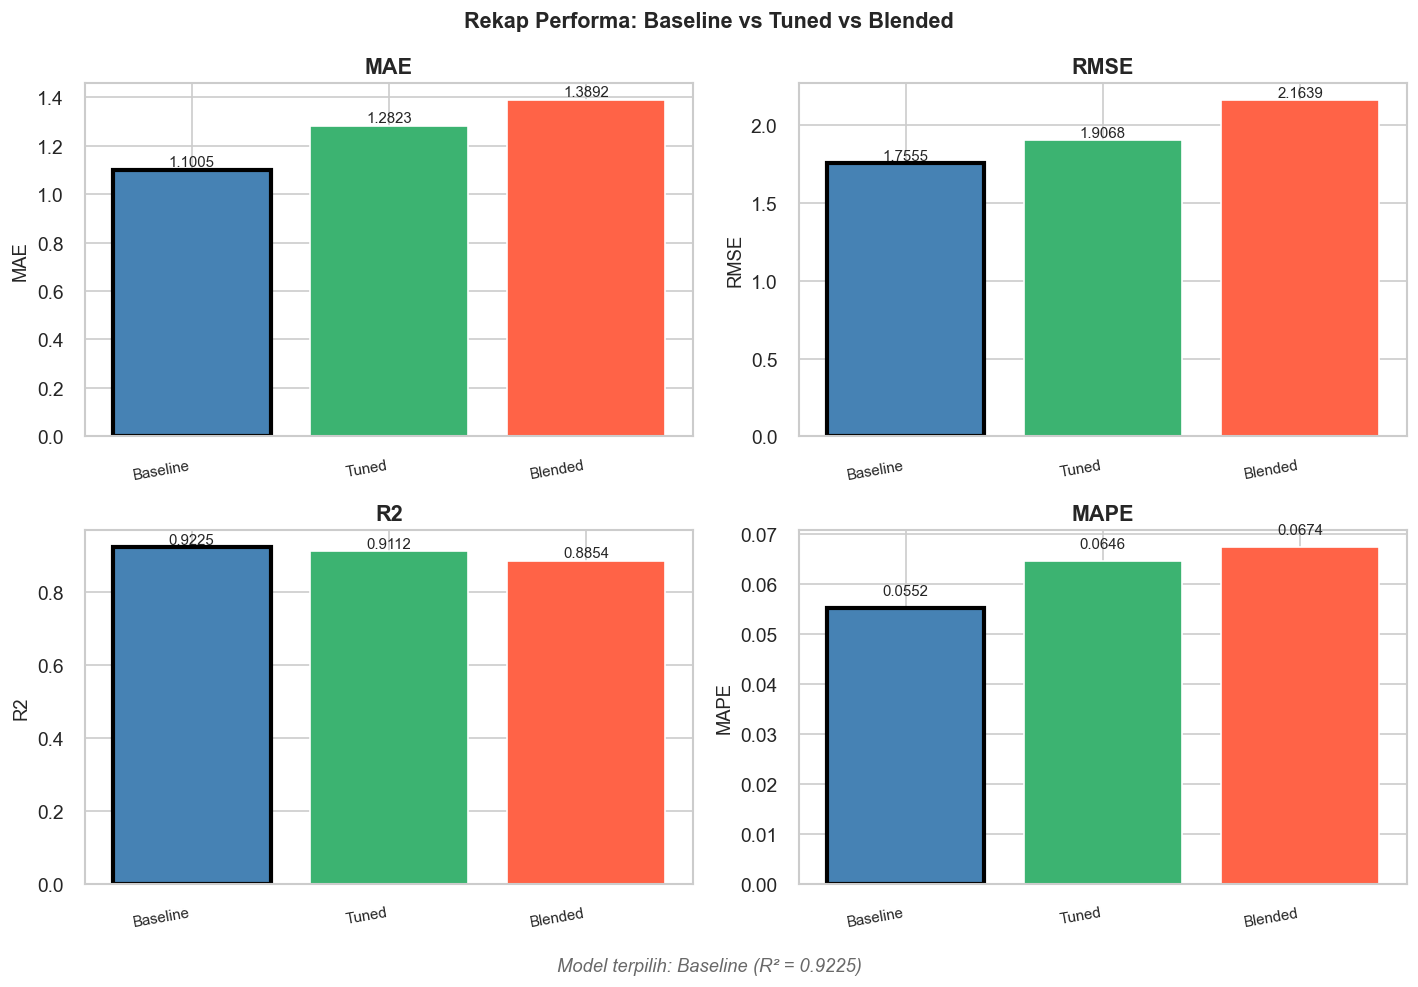

In [70]:
rekap = pd.DataFrame(
    [before_tuning, after_tuning, blend_metrics],
    index=['Baseline', 'Tuned', 'Blended']
).round(4)

metrics = ['MAE', 'RMSE', 'R2', 'MAPE']
colors  = ['steelblue', 'mediumseagreen', 'tomato']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Rekap Performa: Baseline vs Tuned vs Blended',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, metric in enumerate(metrics):
    bars = axes[i].bar(rekap.index, rekap[metric], color=colors)
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].set_xticks(range(len(rekap)))
    axes[i].set_xticklabels(rekap.index, rotation=10, ha='right', fontsize=9)
    for j, (bar, val) in enumerate(zip(bars, rekap[metric])):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=9)
        if rekap.index[j] == chosen_name:
            bar.set_edgecolor('black')
            bar.set_linewidth(2.5)

plt.tight_layout()
fig.text(0.5, -0.02, f'Model terpilih: {chosen_name} (R² = {scores[chosen_name]:.4f})',
         ha='center', fontsize=11, fontstyle='italic', color='dimgray')
fig.savefig("gambar/fig_4_4_3_rekap_blending.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 4.5 Evaluasi Model

### 4.5.1 Validasi Konservatif (Test = Data Asli Saja)


In [71]:
# =============================================================================
# 4.5.1 — DEFINISI df_train_konservatif (diperlukan di section 4.8)
# df_train sudah dibentuk saat setup PyCaret:
#   concat(df_orig_train [80% data asli] + df_synth [seluruh data sintetis])
# =============================================================================

df_train_konservatif = df_train.copy()

print(f"df_train_konservatif : {len(df_train_konservatif)} sampel")
print(f"  - Data asli (train) : {len(df_orig_train)} sampel")
print(f"  - Data sintetis     : {len(df_synth)} sampel")
print(f"df_orig_test         : {len(df_orig_test)} sampel (data asli saja)")


df_train_konservatif : 612 sampel
  - Data asli (train) : 132 sampel
  - Data sintetis     : 480 sampel
df_orig_test         : 34 sampel (data asli saja)


In [72]:
preds  = predict_model(final_cv_model, data=df_orig_test)
y_true = preds['durasi_hari']
y_pred = preds['prediction_label']

mae_k  = skm.mean_absolute_error(y_true, y_pred)
rmse_k = np.sqrt(skm.mean_squared_error(y_true, y_pred))
r2_k   = skm.r2_score(y_true, y_pred)
mape_k = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

residuals = y_true.values - y_pred.values
abs_err   = np.abs(residuals)
idx_sort  = np.argsort(y_true.values)
y_te_s    = y_true.values[idx_sort]
y_pr_s    = y_pred.values[idx_sort]

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,1.0791,2.4612,1.5688,0.8691,0.0707,0.0514


### 4.5.2 Visualisasi Hasil Evaluasi

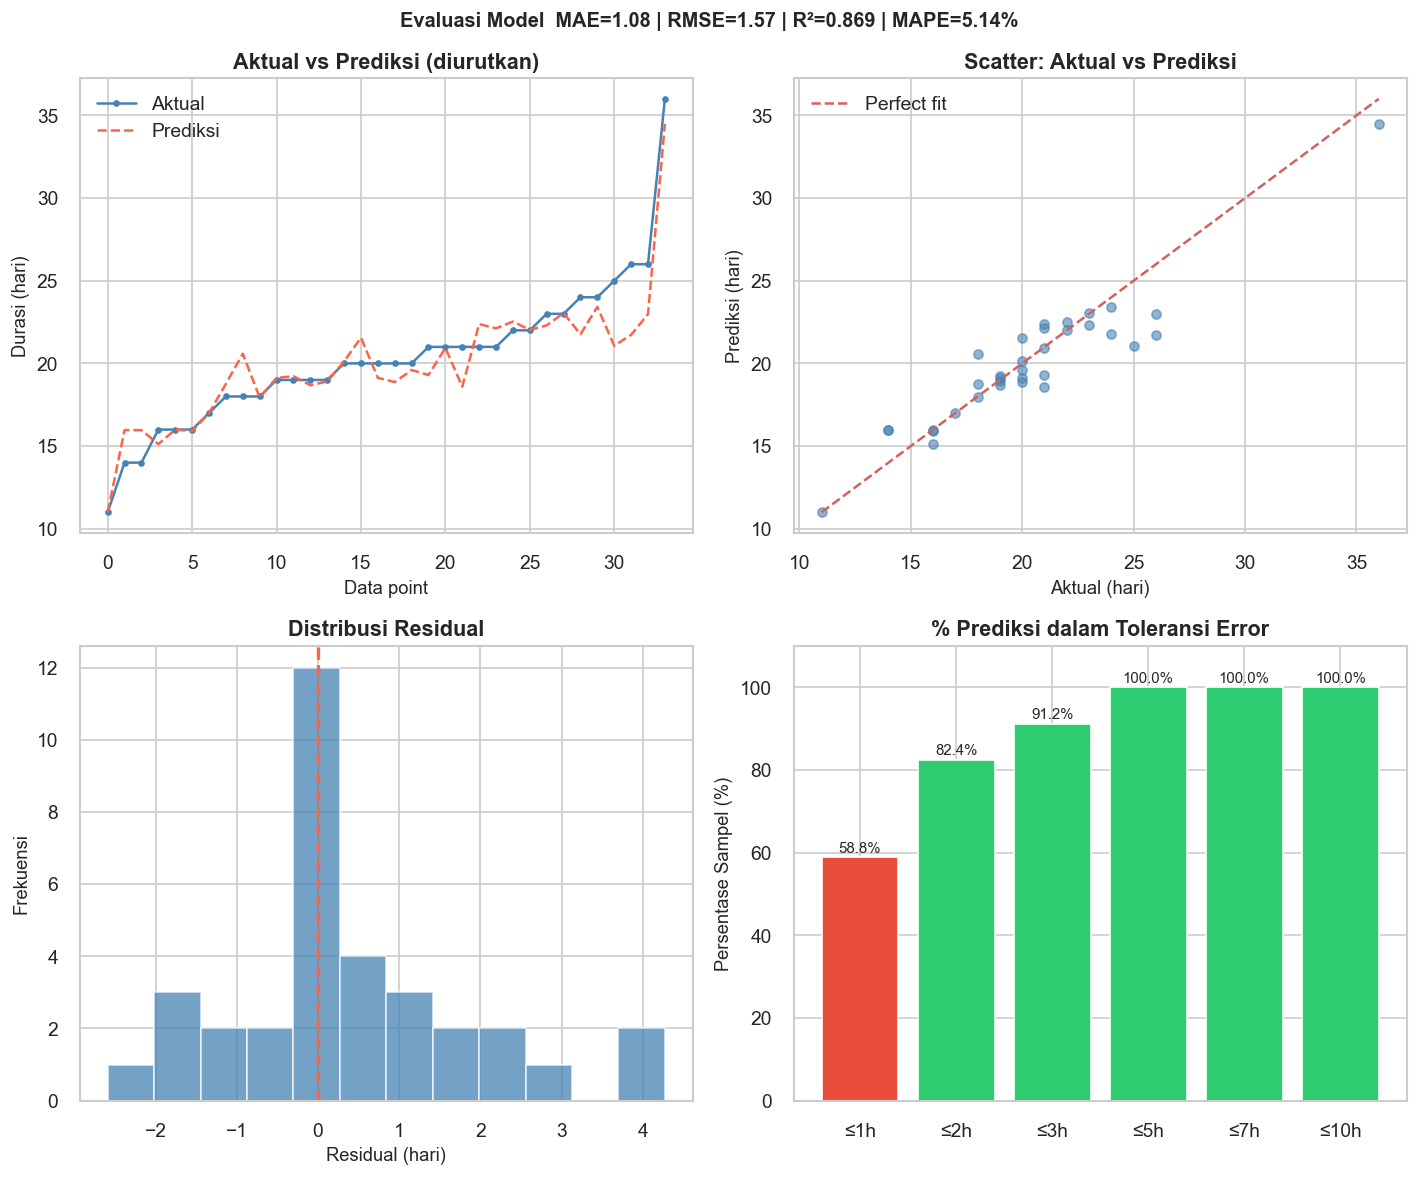

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f'Evaluasi Model  MAE={mae_k:.2f} | RMSE={rmse_k:.2f} | R²={r2_k:.3f} | MAPE={mape_k:.2f}%',
             fontsize=12, fontweight='bold')

axes[0,0].plot(y_te_s, label='Aktual', color='steelblue', marker='o', markersize=4, linewidth=1.5)
axes[0,0].plot(y_pr_s, label='Prediksi', color='tomato', linestyle='--', marker='x', markersize=4, linewidth=1.5)
axes[0,0].set_title('Aktual vs Prediksi (diurutkan)')
axes[0,0].set_xlabel('Data point')
axes[0,0].set_ylabel('Durasi (hari)')
axes[0,0].legend()

min_v, max_v = min(y_te_s.min(), y_pr_s.min()), max(y_te_s.max(), y_pr_s.max())
axes[0,1].scatter(y_te_s, y_pr_s, alpha=0.6, s=30, color='steelblue')
axes[0,1].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5, label='Perfect fit')
axes[0,1].set_title('Scatter: Aktual vs Prediksi')
axes[0,1].set_xlabel('Aktual (hari)')
axes[0,1].set_ylabel('Prediksi (hari)')
axes[0,1].legend()

axes[1,0].hist(residuals, bins=12, color='steelblue', alpha=0.75, edgecolor='white')
axes[1,0].axvline(0, color='tomato', linewidth=2, linestyle='--')
axes[1,0].set_title('Distribusi Residual')
axes[1,0].set_xlabel('Residual (hari)')
axes[1,0].set_ylabel('Frekuensi')

thresholds = [1, 2, 3, 5, 7, 10]
pct_within = [(abs_err <= t).mean()*100 for t in thresholds]
colors_bar = ['#2ecc71' if p >= 80 else '#f39c12' if p >= 60 else '#e74c3c' for p in pct_within]
bars = axes[1,1].bar([f'≤{t}h' for t in thresholds], pct_within, color=colors_bar)
for bar, p in zip(bars, pct_within):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   f'{p:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1,1].set_title('% Prediksi dalam Toleransi Error')
axes[1,1].set_ylabel('Persentase Sampel (%)')
axes[1,1].set_ylim(0, 110)

plt.tight_layout()
fig.savefig('gambar/fig_4_5_2_evaluasi.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5.3 Feature Importance

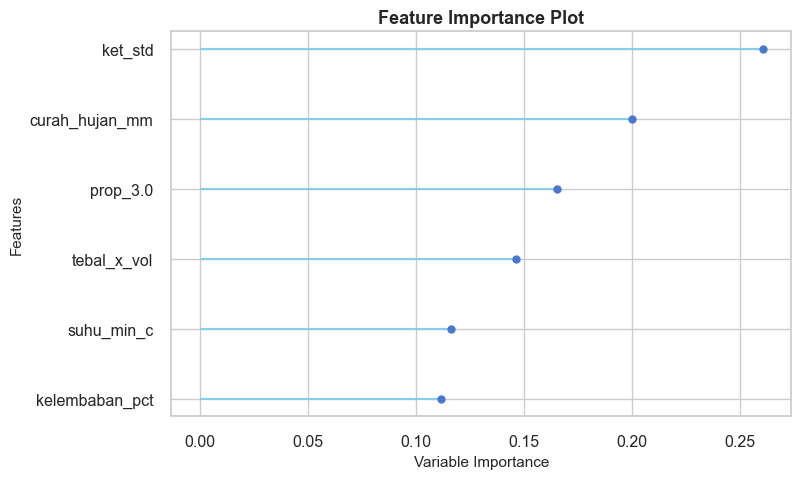

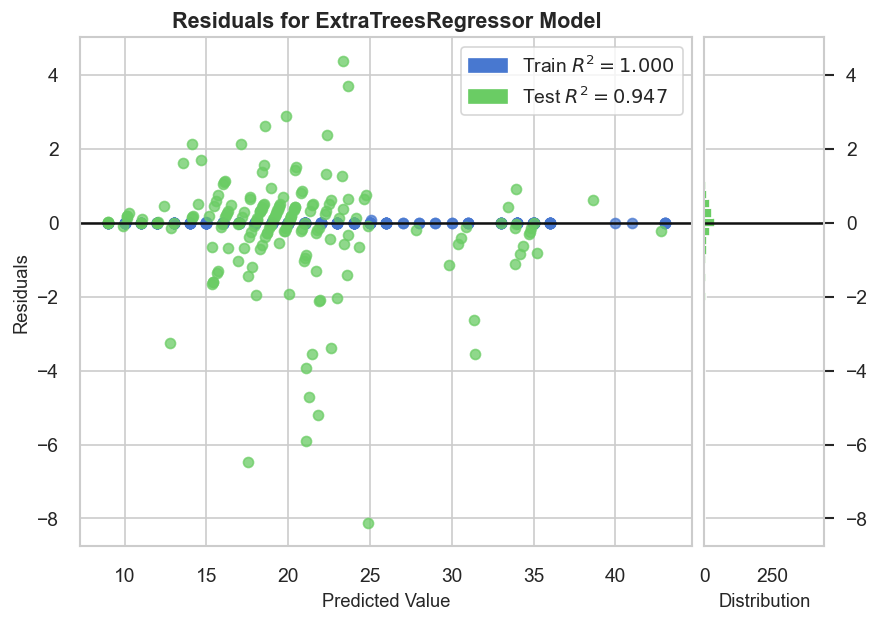

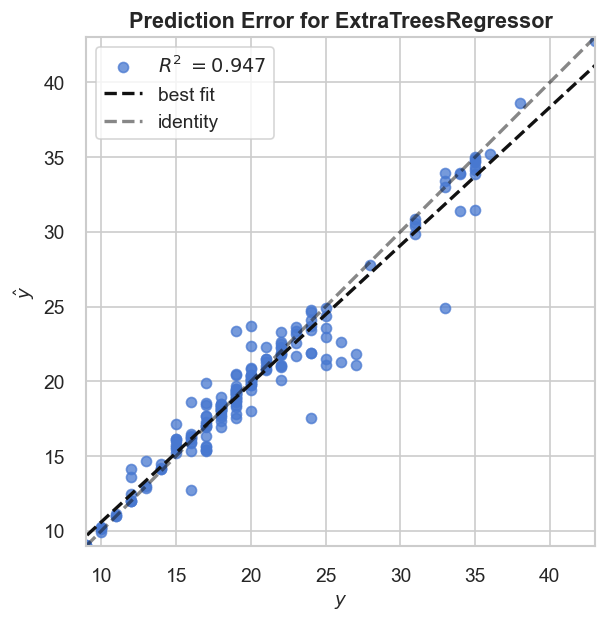

In [74]:
# =============================================================================
# 4.5.3 — FEATURE IMPORTANCE & PyCaret PLOTS
# =============================================================================

try:
    plot_model(final_cv_model, plot='feature', save=False)
except Exception as e:
    print(f"Feature importance: {e}")

try:
    plot_model(final_cv_model, plot='residuals')
    plot_model(final_cv_model, plot='error')
except Exception as e:
    print(f"PyCaret plot error: {e}")


In [75]:
# =============================================================================
# VISUALISASI FEATURE IMPORTANCE — lanjutan dari final_cv_model
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.inspection import permutation_importance
from pycaret.regression import get_config

os.makedirs('gambar', exist_ok=True)

# Ambil pipeline + data dari PyCaret
X_train_t = get_config('X_train_transformed')
y_train_t = get_config('y_train_transformed')
X_test_t  = get_config('X_test_transformed')
y_test_t  = get_config('y_test_transformed')
feat_names = list(X_train_t.columns)

# Coba ambil built-in importance (tree-based)
fi_series = None
try:
    estimator = final_cv_model
    # Blended: rata-rata dari setiap estimator
    if hasattr(estimator, 'estimators_'):
        all_fi = []
        for est in estimator.estimators_:
            if hasattr(est, 'feature_importances_'):
                all_fi.append(est.feature_importances_)
        if all_fi:
            fi_series = pd.Series(np.mean(all_fi, axis=0), index=feat_names)
    elif hasattr(estimator, 'feature_importances_'):
        fi_series = pd.Series(estimator.feature_importances_, index=feat_names)
except:
    pass

# Fallback: permutation importance jika built-in tidak tersedia
if fi_series is None:
    print("Built-in importance tidak tersedia, menghitung permutation importance...")
    perm = permutation_importance(
        final_cv_model, X_test_t, y_test_t,
        n_repeats=15, random_state=SEED, scoring='neg_mean_absolute_error'
    )
    fi_series = pd.Series(perm.importances_mean, index=feat_names)

fi_sorted = fi_series.sort_values(ascending=False)
print(f"Total fitur: {len(fi_sorted)}")
print(fi_sorted.round(4).to_string())

Total fitur: 6
ket_std           0.2606
curah_hujan_mm    0.2001
prop_3.0          0.1653
tebal_x_vol       0.1463
suhu_min_c        0.1161
kelembaban_pct    0.1116


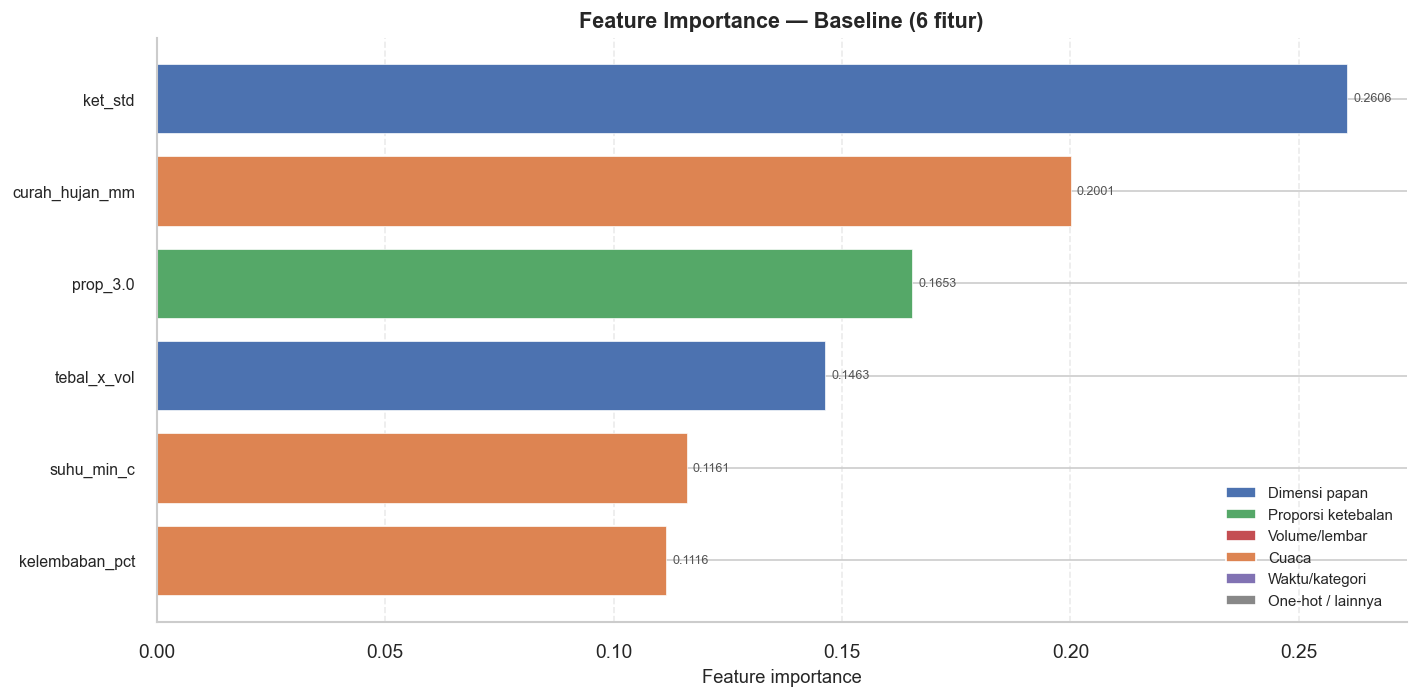

Tersimpan: gambar/fig_fi_all_features.png


In [76]:
# =============================================================================
# PLOT 1 — Semua fitur, horizontal bar, color-coded per grup
# =============================================================================

GRUP = {
    'Dimensi papan'    : ['ket_mean','ket_max','ket_min','ket_std','n_ketebalan',
                          'tebal_x_vol','rasio_tebal','prop_tipis','prop_tebal_ext'],
    'Proporsi ketebalan': ['prop_2.0','prop_2.5','prop_3.0','prop_3.5',
                           'prop_4.0','prop_5.0','prop_8.0'],
    'Volume/lembar'    : ['vol_total_m3','vol_m3_total','lembar_total',
                          'total_lembar','vol_per_lembar','jumlah_asal'],
    'Cuaca'            : ['kelembaban_pct','curah_hujan_mm','suhu_maks_c',
                          'suhu_min_c','delta_suhu','lembab_x_tebal','hujan_x_lembab'],
    'Waktu/kategori'   : ['bulan_in','musim','no_kiln','jenis_kayu'],
}
WARNA = {
    'Dimensi papan'    : '#4C72B0',
    'Proporsi ketebalan': '#55A868',
    'Volume/lembar'    : '#C44E52',
    'Cuaca'            : '#DD8452',
    'Waktu/kategori'   : '#8172B3',
}

def get_color(feat):
    for grup, feats in GRUP.items():
        if any(feat.startswith(f) or feat == f for f in feats):
            return WARNA[grup]
    return '#888888'  # abu untuk fitur one-hot encoding

colors  = [get_color(f) for f in fi_sorted.index]
n_feats = len(fi_sorted)
fig_h   = max(6, n_feats * 0.32)

fig, ax = plt.subplots(figsize=(12, fig_h))
bars = ax.barh(range(n_feats), fi_sorted.values, color=colors,
               edgecolor='white', linewidth=0.4, height=0.75)

ax.set_yticks(range(n_feats))
ax.set_yticklabels(fi_sorted.index, fontsize=9.5)
ax.invert_yaxis()
ax.set_xlabel('Feature importance', fontsize=11)
ax.set_title(f'Feature Importance — {chosen_name} ({n_feats} fitur)',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Anotasi nilai di ujung bar
vmax = fi_sorted.values.max()
for bar, val in zip(bars, fi_sorted.values):
    if val > vmax * 0.01:
        ax.text(val + vmax*0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=7.5, color='#555')

# Legenda kelompok fitur
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=v, label=k) for k, v in WARNA.items()]
legend_els.append(Patch(facecolor='#888888', label='One-hot / lainnya'))
ax.legend(handles=legend_els, fontsize=9, loc='lower right',
          framealpha=0.85, edgecolor='#ccc')

plt.tight_layout()
fname = 'gambar/fig_fi_all_features.png'
fig.savefig(fname, dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print(f"Tersimpan: {fname}")

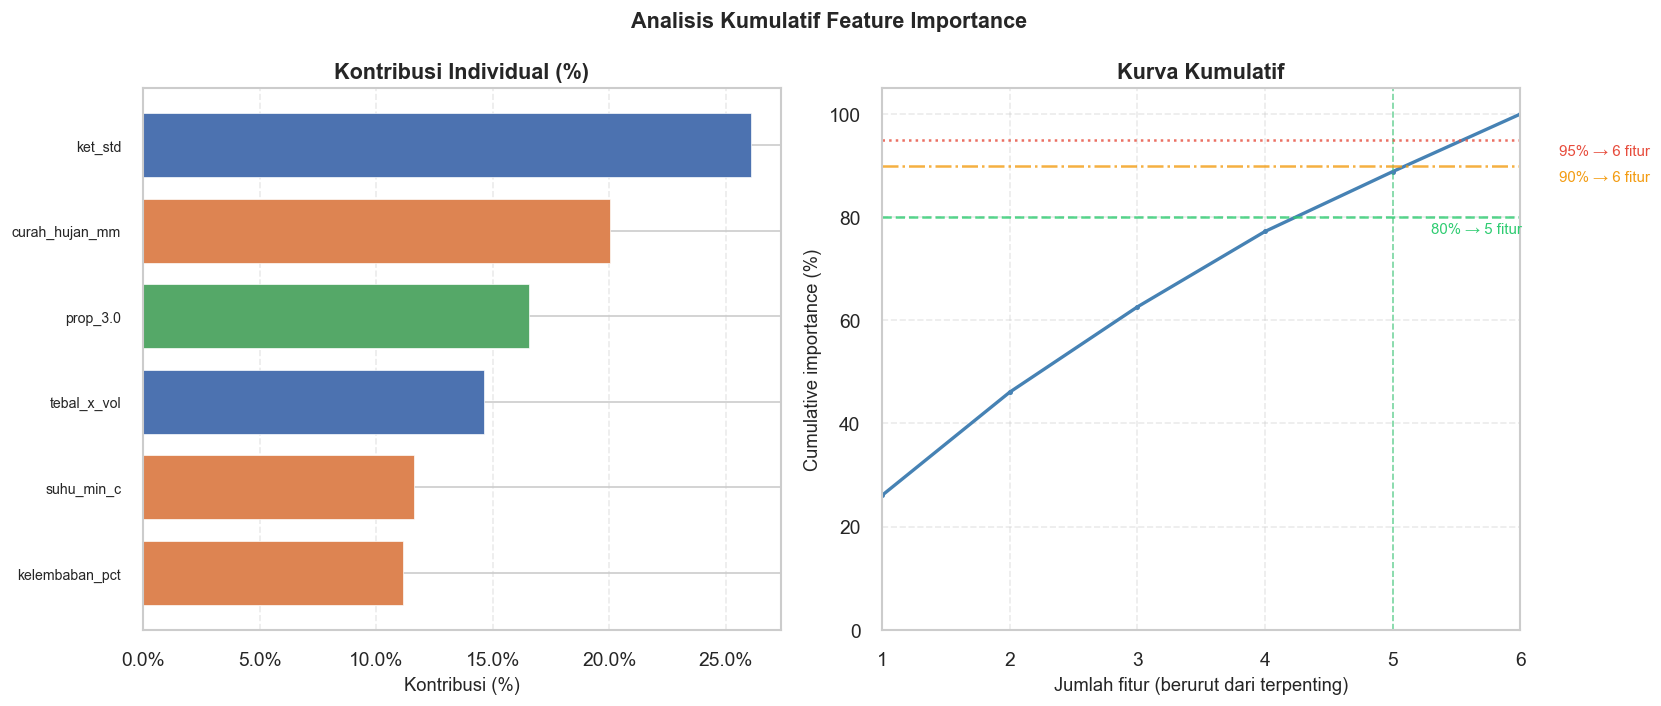

Tersimpan: gambar/fig_fi_cumulative.png
80% importance → 5 fitur: ['ket_std', 'curah_hujan_mm', 'prop_3.0', 'tebal_x_vol', 'suhu_min_c']
90% importance → 6 fitur: ['ket_std', 'curah_hujan_mm', 'prop_3.0', 'tebal_x_vol', 'suhu_min_c', 'kelembaban_pct']
95% importance → 6 fitur: ['ket_std', 'curah_hujan_mm', 'prop_3.0', 'tebal_x_vol', 'suhu_min_c', 'kelembaban_pct']


In [77]:
# =============================================================================
# PLOT 2 — Cumulative importance: berapa fitur untuk 80% / 90% / 95%?
# =============================================================================

fi_pct = fi_sorted / fi_sorted.sum() * 100
fi_cum = fi_pct.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, fig_h))
fig.suptitle('Analisis Kumulatif Feature Importance', fontsize=13, fontweight='bold')

# Panel kiri: kontribusi individual (%)
ax = axes[0]
colors_pct = [get_color(f) for f in fi_pct.index]
ax.barh(range(n_feats), fi_pct.values, color=colors_pct,
        edgecolor='white', linewidth=0.4, height=0.75)
ax.set_yticks(range(n_feats))
ax.set_yticklabels(fi_pct.index, fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel('Kontribusi (%)')
ax.set_title('Kontribusi Individual (%)', fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

# Panel kanan: kurva kumulatif + threshold lines
ax2 = axes[1]
ax2.plot(range(1, n_feats+1), fi_cum.values,
         color='steelblue', linewidth=2, marker='o', markersize=3)

for thresh, col, ls in [(80,'#2ecc71','--'),(90,'#f39c12','-.'),(95,'#e74c3c',':')]:
    n_needed = (fi_cum <= thresh).sum() + 1
    ax2.axhline(thresh, color=col, linestyle=ls, linewidth=1.5, alpha=0.8)
    ax2.axvline(n_needed, color=col, linestyle=ls, linewidth=1, alpha=0.6)
    ax2.text(n_needed+0.3, thresh-3, f'{thresh}% → {n_needed} fitur',
             fontsize=9, color=col)

ax2.set_xlabel('Jumlah fitur (berurut dari terpenting)')
ax2.set_ylabel('Cumulative importance (%)')
ax2.set_title('Kurva Kumulatif', fontweight='bold')
ax2.set_xlim(1, n_feats)
ax2.set_ylim(0, 105)
ax2.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
fname2 = 'gambar/fig_fi_cumulative.png'
fig.savefig(fname2, dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print(f"Tersimpan: {fname2}")

# Ringkasan threshold
for t in [80, 90, 95]:
    n = (fi_cum <= t).sum() + 1
    top = fi_sorted.index[:n].tolist()
    print(f"{t}% importance → {n} fitur: {top}")

In [78]:
print(fi_sorted.round(4).to_string())
print()
fi_pct = fi_sorted / fi_sorted.sum() * 100
print(fi_pct.round(2).to_string())
print()
for t in [80, 90, 95]:
    n = (fi_pct.cumsum() <= t).sum() + 1
    print(f"{t}% → {n} fitur: {fi_sorted.index[:n].tolist()}")

ket_std           0.2606
curah_hujan_mm    0.2001
prop_3.0          0.1653
tebal_x_vol       0.1463
suhu_min_c        0.1161
kelembaban_pct    0.1116

ket_std           26.06
curah_hujan_mm    20.01
prop_3.0          16.53
tebal_x_vol       14.63
suhu_min_c        11.61
kelembaban_pct    11.16

80% → 5 fitur: ['ket_std', 'curah_hujan_mm', 'prop_3.0', 'tebal_x_vol', 'suhu_min_c']
90% → 6 fitur: ['ket_std', 'curah_hujan_mm', 'prop_3.0', 'tebal_x_vol', 'suhu_min_c', 'kelembaban_pct']
95% → 6 fitur: ['ket_std', 'curah_hujan_mm', 'prop_3.0', 'tebal_x_vol', 'suhu_min_c', 'kelembaban_pct']


---
## 4.6 Deployment Model

### 4.6.1 Penyimpanan Model


In [79]:
# =============================================================================
# 4.6.1 — FINALIZE & SIMPAN MODEL
# finalize_model() melatih ulang pada SELURUH data sebelum disimpan.
# =============================================================================

final_model = finalize_model(final_cv_model)
save_model(final_model, 'model_prediksi_kiln_v1')
print('Model tersimpan: model_prediksi_kiln_v1.pkl')
print(f'Ukuran file: {os.path.getsize("model_prediksi_kiln_v1.pkl") / 1024:.1f} KB')


Transformation Pipeline and Model Successfully Saved
Model tersimpan: model_prediksi_kiln_v1.pkl
Ukuran file: 4547.9 KB


### 4.6.2 Pembuatan API (Flask)

In [80]:
# =============================================================================
# 4.6.2 — TEMPLATE KODE API (Flask)
# Jalankan kode ini sebagai file terpisah: app.py
# =============================================================================

api_code = '''
from flask import Flask, request, jsonify
from pycaret.regression import load_model, predict_model
import pandas as pd

app   = Flask(__name__)
model = load_model("model_prediksi_kiln_v1")

TEBAL_BINS   = [2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 8.0]
CAT_FEATURES = ["jenis_kayu", "no_kiln", "bulan_in", "musim"]

def build_input_row(payload: dict) -> pd.DataFrame:
    # Ubah payload JSON menjadi DataFrame sesuai format model.
    komposisi = payload["komposisi_ketebalan"]
    total_lem = sum(komposisi.values())
    props = {f"prop_{t}": komposisi.get(str(t), 0) / total_lem for t in TEBAL_BINS}
    import numpy as np
    tebal_vals   = [float(t) for t, n in komposisi.items() for _ in range(n)]
    ket_mean     = np.mean(tebal_vals)
    ket_max, ket_min = max(tebal_vals), min(tebal_vals)
    ket_std      = float(np.std(tebal_vals)) if len(set(tebal_vals)) > 1 else 0.0
    delta_suhu   = payload["suhu_maks_c"] - payload["suhu_min_c"]
    bulan_in     = int(payload["bulan_in"])
    musim        = 1 if bulan_in in [11,12,1,2,3,4] else 0
    prop_tipis   = props["prop_2.0"] + props["prop_2.5"]
    prop_tebal_e = props["prop_5.0"] + props["prop_8.0"]

    row = {
        "jenis_kayu"    : str(payload["jenis_kayu"]),
        "no_kiln"       : str(payload["no_kiln"]),
        "vol_total_m3"  : payload["vol_total_m3"],
        "total_lembar"  : payload["total_lembar"],
        "kelembaban_pct": payload["kelembaban_pct"],
        "curah_hujan_mm": payload["curah_hujan_mm"],
        "suhu_maks_c"   : payload["suhu_maks_c"],
        "suhu_min_c"    : payload["suhu_min_c"],
        "bulan_in"      : str(bulan_in),
        "ket_mean"      : ket_mean, "ket_max": ket_max, "ket_min": ket_min,
        "ket_std"       : ket_std,  "n_ketebalan": len(set(tebal_vals)),
        "vol_m3_total"  : payload["vol_total_m3"],
        "lembar_total"  : payload["total_lembar"],
        "jumlah_asal"   : payload.get("jumlah_asal", 1),
        "vol_per_lembar": payload["vol_total_m3"] / max(payload["total_lembar"], 1),
        "delta_suhu"    : delta_suhu,
        "musim"         : str(musim),
        "lembab_x_tebal": payload["kelembaban_pct"] * ket_max,
        "hujan_x_lembab": payload["curah_hujan_mm"] * payload["kelembaban_pct"],
        "tebal_x_vol"   : ket_mean * payload["vol_total_m3"],
        "prop_tipis"    : prop_tipis,
        "prop_tebal_ext": prop_tebal_e,
        "rasio_tebal"   : prop_tebal_e / (prop_tipis + 1e-6),
        **props,
    }
    return pd.DataFrame([row])

@app.route("/predict", methods=["POST"])
def predict():
    try:
        payload = request.get_json(force=True)
        df_input = build_input_row(payload)
        hasil    = predict_model(model, data=df_input)
        durasi   = round(float(hasil["prediction_label"].values[0]), 1)
        return jsonify({"status": "success", "prediksi_durasi_hari": durasi})
    except Exception as e:
        return jsonify({"status": "error", "message": str(e)}), 400

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000, debug=False)
'''

print("Template API Flask:")
print(api_code)


Template API Flask:

from flask import Flask, request, jsonify
from pycaret.regression import load_model, predict_model
import pandas as pd

app   = Flask(__name__)
model = load_model("model_prediksi_kiln_v1")

TEBAL_BINS   = [2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 8.0]
CAT_FEATURES = ["jenis_kayu", "no_kiln", "bulan_in", "musim"]

def build_input_row(payload: dict) -> pd.DataFrame:
    # Ubah payload JSON menjadi DataFrame sesuai format model.
    komposisi = payload["komposisi_ketebalan"]
    total_lem = sum(komposisi.values())
    props = {f"prop_{t}": komposisi.get(str(t), 0) / total_lem for t in TEBAL_BINS}
    import numpy as np
    tebal_vals   = [float(t) for t, n in komposisi.items() for _ in range(n)]
    ket_mean     = np.mean(tebal_vals)
    ket_max, ket_min = max(tebal_vals), min(tebal_vals)
    ket_std      = float(np.std(tebal_vals)) if len(set(tebal_vals)) > 1 else 0.0
    delta_suhu   = payload["suhu_maks_c"] - payload["suhu_min_c"]
    bulan_in     = int(payload["bulan_in"])
 

### 4.6.3 Pengujian Aplikasi

In [81]:
# =============================================================================
# 4.6.3 — FUNGSI PREDIKSI & PENGUJIAN
# =============================================================================

def build_input_row(
    jenis_kayu, no_kiln, vol_total_m3, total_lembar,
    kelembaban_pct, curah_hujan_mm, suhu_maks_c, suhu_min_c,
    bulan_in, komposisi_ketebalan, jumlah_asal=1
):
    total_lem  = sum(komposisi_ketebalan.values())
    props      = {f'prop_{t}': komposisi_ketebalan.get(t, 0) / total_lem for t in TEBAL_BINS}
    tebal_vals = np.repeat(list(komposisi_ketebalan.keys()), list(komposisi_ketebalan.values())).astype(float)
    ket_mean   = tebal_vals.mean(); ket_max = tebal_vals.max(); ket_min = tebal_vals.min()
    ket_std    = tebal_vals.std() if len(set(komposisi_ketebalan.keys())) > 1 else 0.0
    delta_suhu = suhu_maks_c - suhu_min_c
    musim      = 1 if bulan_in in [11,12,1,2,3,4] else 0
    prop_tipis = props['prop_2.0'] + props['prop_2.5']
    prop_te    = props['prop_5.0'] + props['prop_8.0']

    row = {
        'jenis_kayu': str(jenis_kayu), 'no_kiln': str(no_kiln),
        'vol_total_m3': vol_total_m3,  'total_lembar': total_lembar,
        'kelembaban_pct': kelembaban_pct, 'curah_hujan_mm': curah_hujan_mm,
        'suhu_maks_c': suhu_maks_c,    'suhu_min_c': suhu_min_c,
        'bulan_in': str(bulan_in),     'ket_mean': ket_mean,
        'ket_max': ket_max,            'ket_min': ket_min,
        'ket_std': ket_std,            'n_ketebalan': len(komposisi_ketebalan),
        'vol_m3_total': vol_total_m3,  'lembar_total': total_lembar,
        'jumlah_asal': jumlah_asal,    'vol_per_lembar': vol_total_m3/max(total_lembar,1),
        'delta_suhu': delta_suhu,      'musim': str(musim),
        'lembab_x_tebal': kelembaban_pct*ket_max, 'hujan_x_lembab': curah_hujan_mm*kelembaban_pct,
        'tebal_x_vol': ket_mean*vol_total_m3, 'prop_tipis': prop_tipis,
        'prop_tebal_ext': prop_te,     'rasio_tebal': prop_te/(prop_tipis+1e-6),
        **{k: v for k, v in props.items()},
    }
    return pd.DataFrame([row])

def predict_durasi(jenis_kayu, no_kiln, vol_total_m3, total_lembar,
                   kelembaban_pct, curah_hujan_mm, suhu_maks_c, suhu_min_c,
                   bulan_in, komposisi_ketebalan, jumlah_asal=1, model=None):
    if model is None: model = load_model('model_prediksi_kiln_v1')
    df_input = build_input_row(jenis_kayu, no_kiln, vol_total_m3, total_lembar,
                                kelembaban_pct, curah_hujan_mm, suhu_maks_c, suhu_min_c,
                                bulan_in, komposisi_ketebalan, jumlah_asal)
    hasil = predict_model(model, data=df_input)
    return round(float(hasil['prediction_label'].values[0]), 1)


# ── Test Case Pengujian ─────────────────────────────────────────────────────
test_cases = [
    dict(nama="Mahoni · Musim Hujan · Tebal Tipis",
         args=dict(jenis_kayu='MAHONI', no_kiln=1, vol_total_m3=12.5, total_lembar=800,
                   kelembaban_pct=87., curah_hujan_mm=8., suhu_maks_c=29., suhu_min_c=23.,
                   bulan_in=2, komposisi_ketebalan={2.5:500, 3.0:200, 4.0:100})),
    dict(nama="Jati · Musim Kemarau · Tebal Besar",
         args=dict(jenis_kayu='JATI', no_kiln=2, vol_total_m3=8., total_lembar=400,
                   kelembaban_pct=74., curah_hujan_mm=1.5, suhu_maks_c=32.5, suhu_min_c=24.,
                   bulan_in=7, komposisi_ketebalan={3.0:100, 5.0:200, 8.0:100})),
    dict(nama="Mahoni · Musim Kemarau · Mix Ketebalan",
         args=dict(jenis_kayu='MAHONI', no_kiln=3, vol_total_m3=15., total_lembar=900,
                   kelembaban_pct=70., curah_hujan_mm=2., suhu_maks_c=34., suhu_min_c=25.,
                   bulan_in=8, komposisi_ketebalan={2.0:200, 3.0:400, 5.0:200, 8.0:100})),
]

print("=" * 55)
print("  HASIL PENGUJIAN PREDIKSI BATCH BARU")
print("=" * 55)
results_test = []
for tc in test_cases:
    pred = predict_durasi(**tc['args'], model=final_model)
    print(f"  {tc['nama']}")
    print(f"    → Prediksi durasi: {pred} hari")
    results_test.append({'Skenario': tc['nama'], 'Prediksi (hari)': pred})

print("\nRingkasan:")
print(pd.DataFrame(results_test).to_string(index=False))


  HASIL PENGUJIAN PREDIKSI BATCH BARU


  Mahoni · Musim Hujan · Tebal Tipis
    → Prediksi durasi: 17.4 hari


  Jati · Musim Kemarau · Tebal Besar
    → Prediksi durasi: 19.4 hari


  Mahoni · Musim Kemarau · Mix Ketebalan
    → Prediksi durasi: 19.9 hari

Ringkasan:
                              Skenario  Prediksi (hari)
    Mahoni · Musim Hujan · Tebal Tipis             17.4
    Jati · Musim Kemarau · Tebal Besar             19.4
Mahoni · Musim Kemarau · Mix Ketebalan             19.9


In [82]:
# =============================================================================
# 4.6.3 — VISUALISASI HASIL PENGUJIAN (Bar Chart Skenario)
# =============================================================================

df_test_vis = pd.DataFrame(results_test)

fig, ax = plt.subplots(figsize=(9, 4))
colors  = sns.color_palette('muted', len(df_test_vis))
bars    = ax.barh(df_test_vis['Skenario'], df_test_vis['Prediksi (hari)'], color=colors)
ax.set_title('Prediksi Durasi Pengeringan — Skenario Pengujian', fontsize=13, fontweight='bold')
ax.set_xlabel('Durasi (hari)')
for bar, val in zip(bars, df_test_vis['Prediksi (hari)']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} hari', va='center', fontsize=10)
ax.set_xlim(0, df_test_vis['Prediksi (hari)'].max() * 1.25)
ax.invert_yaxis()
plt.tight_layout()
fig.savefig("gambar/fig_4_6_3_skenario_pengujian.png", dpi=150, bbox_inches="tight")
plt.close()
plt.show()


---
## 4.7 Analisis Hasil dan Pembahasan

### 4.7.1 Rekap Performa Model


In [83]:
# =============================================================================
# 4.7.1 — REKAP PERFORMA MODEL
# =============================================================================

rekap = pd.DataFrame({
    'Tahap'     : ['CV (sebelum tuning)', 'CV (sesudah tuning)', 'CV (blended)', 'Validasi konservatif'],
    'MAE'       : [before_tuning['MAE'], after_tuning['MAE'], blend_metrics['MAE'], mae_k],
    'RMSE'      : [before_tuning['RMSE'], after_tuning['RMSE'], blend_metrics['RMSE'], rmse_k],
    'R²'        : [before_tuning['R2'], after_tuning['R2'], blend_metrics['R2'], r2_k],
}).round(4)

print(rekap.to_string(index=False))


               Tahap    MAE   RMSE     R²
 CV (sebelum tuning) 1.1005 1.7555 0.9225
 CV (sesudah tuning) 1.2823 1.9068 0.9112
        CV (blended) 1.3892 2.1639 0.8854
Validasi konservatif 1.0791 1.5688 0.8691


In [84]:
# =============================================================================
# 4.7.1 — VISUALISASI REKAP PERFORMA SELURUH TAHAP
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Rekap Performa Model Seluruh Tahap', fontsize=13, fontweight='bold')

palette = sns.color_palette('muted', len(rekap))
for i, metric in enumerate(['MAE', 'RMSE', 'R²']):
    bars = axes[i].bar(range(len(rekap)), rekap[metric], color=palette)
    axes[i].set_xticks(range(len(rekap)))
    axes[i].set_xticklabels(rekap['Tahap'], rotation=15, ha='right', fontsize=8)
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    for bar, val in zip(bars, rekap[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
fig.savefig("gambar/fig_4_7_1_rekap_performa.png", dpi=150, bbox_inches="tight")
plt.close()
plt.show()
